# Fig 3 — Spatial examples, transcriptome programs, and HLA associations

Execute cells in order.

Set `DLBCL_DATA_DIR` before the setup cell to override the data root.
Example: `DLBCL_DATA_DIR = '/path/to/data'`

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dlbcl.notebook_setup import run_notebook_setup

_ctx = run_notebook_setup('discovery_archetype', 'fig3')
REPO_ROOT = _ctx.repo_root
_paths = _ctx.paths
FIG_DIR = _ctx.fig_dir
adata = _ctx.adata
arch_df = _ctx.arch_df
pred = _ctx.pred
gep = _ctx.gep
surv = _ctx.surv
archetype_label = _ctx.archetype_label
PATIENT_SUBSET = _ctx.patient_subset
OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Override data root: export DLBCL_DATA_DIR=/path/to/data before running.
print(f"AnnData: {_paths.adata_path}")
print(f"Figures: {FIG_DIR}")

import gc

import pandas as pd
import scanpy as sc

ADATA_PATH = _paths.adata_path

import gc
import math
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

from dlbcl.phenotype_labels import ensure_phenotype_30_labels, read_celltype_colormap_30
from dlbcl.segmentation_overlays import run_for_all_fovs

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

DATA_DIR = _paths.data_dir
adata_full = adata

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, rel_path, write_supplementary_table
subset = None  # nb8 classifier associations: filtered AnnData or None for all patients


AnnData: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/data/DLBCL_location_2026.h5ad
Figures: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/fig3


## Fig 3A–C — Spatial segmentation examples

Colored segmentation overlays (filled masks + borders) for selected fields of view, plus grouped cell-type legends (Fig S2J).

| Panel | Field of view | Main output |
|-------|---------------|-------------|
| S2J | `Tonsil394_1` (reference) + legends | `figures/notebook3/segment_img_for_overlay_{30,16}/` |
| 3A | `T45_2` | `figures/notebook3/segment_img_for_overlay_30/T45_2_*` |
| 3B | `T70_1` | `figures/notebook3/segment_img_for_overlay_30/T70_1_*` |
| 3C | `T28_2` | `figures/notebook3/segment_img_for_overlay_30/T28_2_*` |

Requires `adata.uns['spatial'][fov]` segmentation masks and `celltype_colormap_30` / `celltype_colormap_16`.

**Data:** `data/DLBCL_location_2026.h5ad` — set `DLBCL_DATA_DIR` to override the data root.

In [2]:
# Spatial panels use all unfiltered single cells (all discovery patients).
from dlbcl.phenotype_labels import ensure_phenotype_30_labels

ensure_phenotype_30_labels(adata)
adata = adata[adata.obs["filtering_status"] == "Unfiltered"].copy()
print(f"Spatial overlay cells: {adata.n_obs:,} | FOVs: {adata.obs['fov'].nunique()}")


Spatial overlay cells: 1,316,220 | FOVs: 162


## Fig 3A–C + S2J — fine (30-type) segmentation overlays

In [3]:
# 3A=T45_2, 3B=T70_1, 3C=T28_2; Tonsil394_1 = S2J reference
run_for_all_fovs(
    adata=adata,
    phenotype_key="phenotype_30_bm",
    color_map_key="celltype_colormap_30",
    save_dir=str(FIG_DIR / "segment_img_for_overlay_30"),
    restrict_to_fovs=["Tonsil394_1", "T45_2", "T70_1", "T28_2"],
    fallback_color="#000000",
)


Processing FOVs:   0%|          | 0/4 [00:00<?, ?it/s]

Processing FOVs:  25%|██▌       | 1/4 [00:06<00:18,  6.12s/it]

Processing FOVs:  50%|█████     | 2/4 [00:09<00:08,  4.33s/it]

Processing FOVs:  75%|███████▌  | 3/4 [00:17<00:06,  6.01s/it]

Processing FOVs: 100%|██████████| 4/4 [00:29<00:00,  8.31s/it]

Processing FOVs: 100%|██████████| 4/4 [00:29<00:00,  7.26s/it]

## S2J — tonsil reference, coarse (16-type) overlay

In [4]:
run_for_all_fovs(
    adata=adata,
    phenotype_key="phenotype_16_bm",
    color_map_key="celltype_colormap_16",
    save_dir=str(FIG_DIR / "segment_img_for_overlay_16"),
    restrict_to_fovs=["Tonsil394_1"],
    fallback_color="#000000",
)


Processing FOVs:   0%|          | 0/1 [00:00<?, ?it/s]

Processing FOVs: 100%|██████████| 1/1 [00:11<00:00, 11.68s/it]

Processing FOVs: 100%|██████████| 1/1 [00:11<00:00, 11.68s/it]

## S2J — grouped cell-type legends (30 + 16)

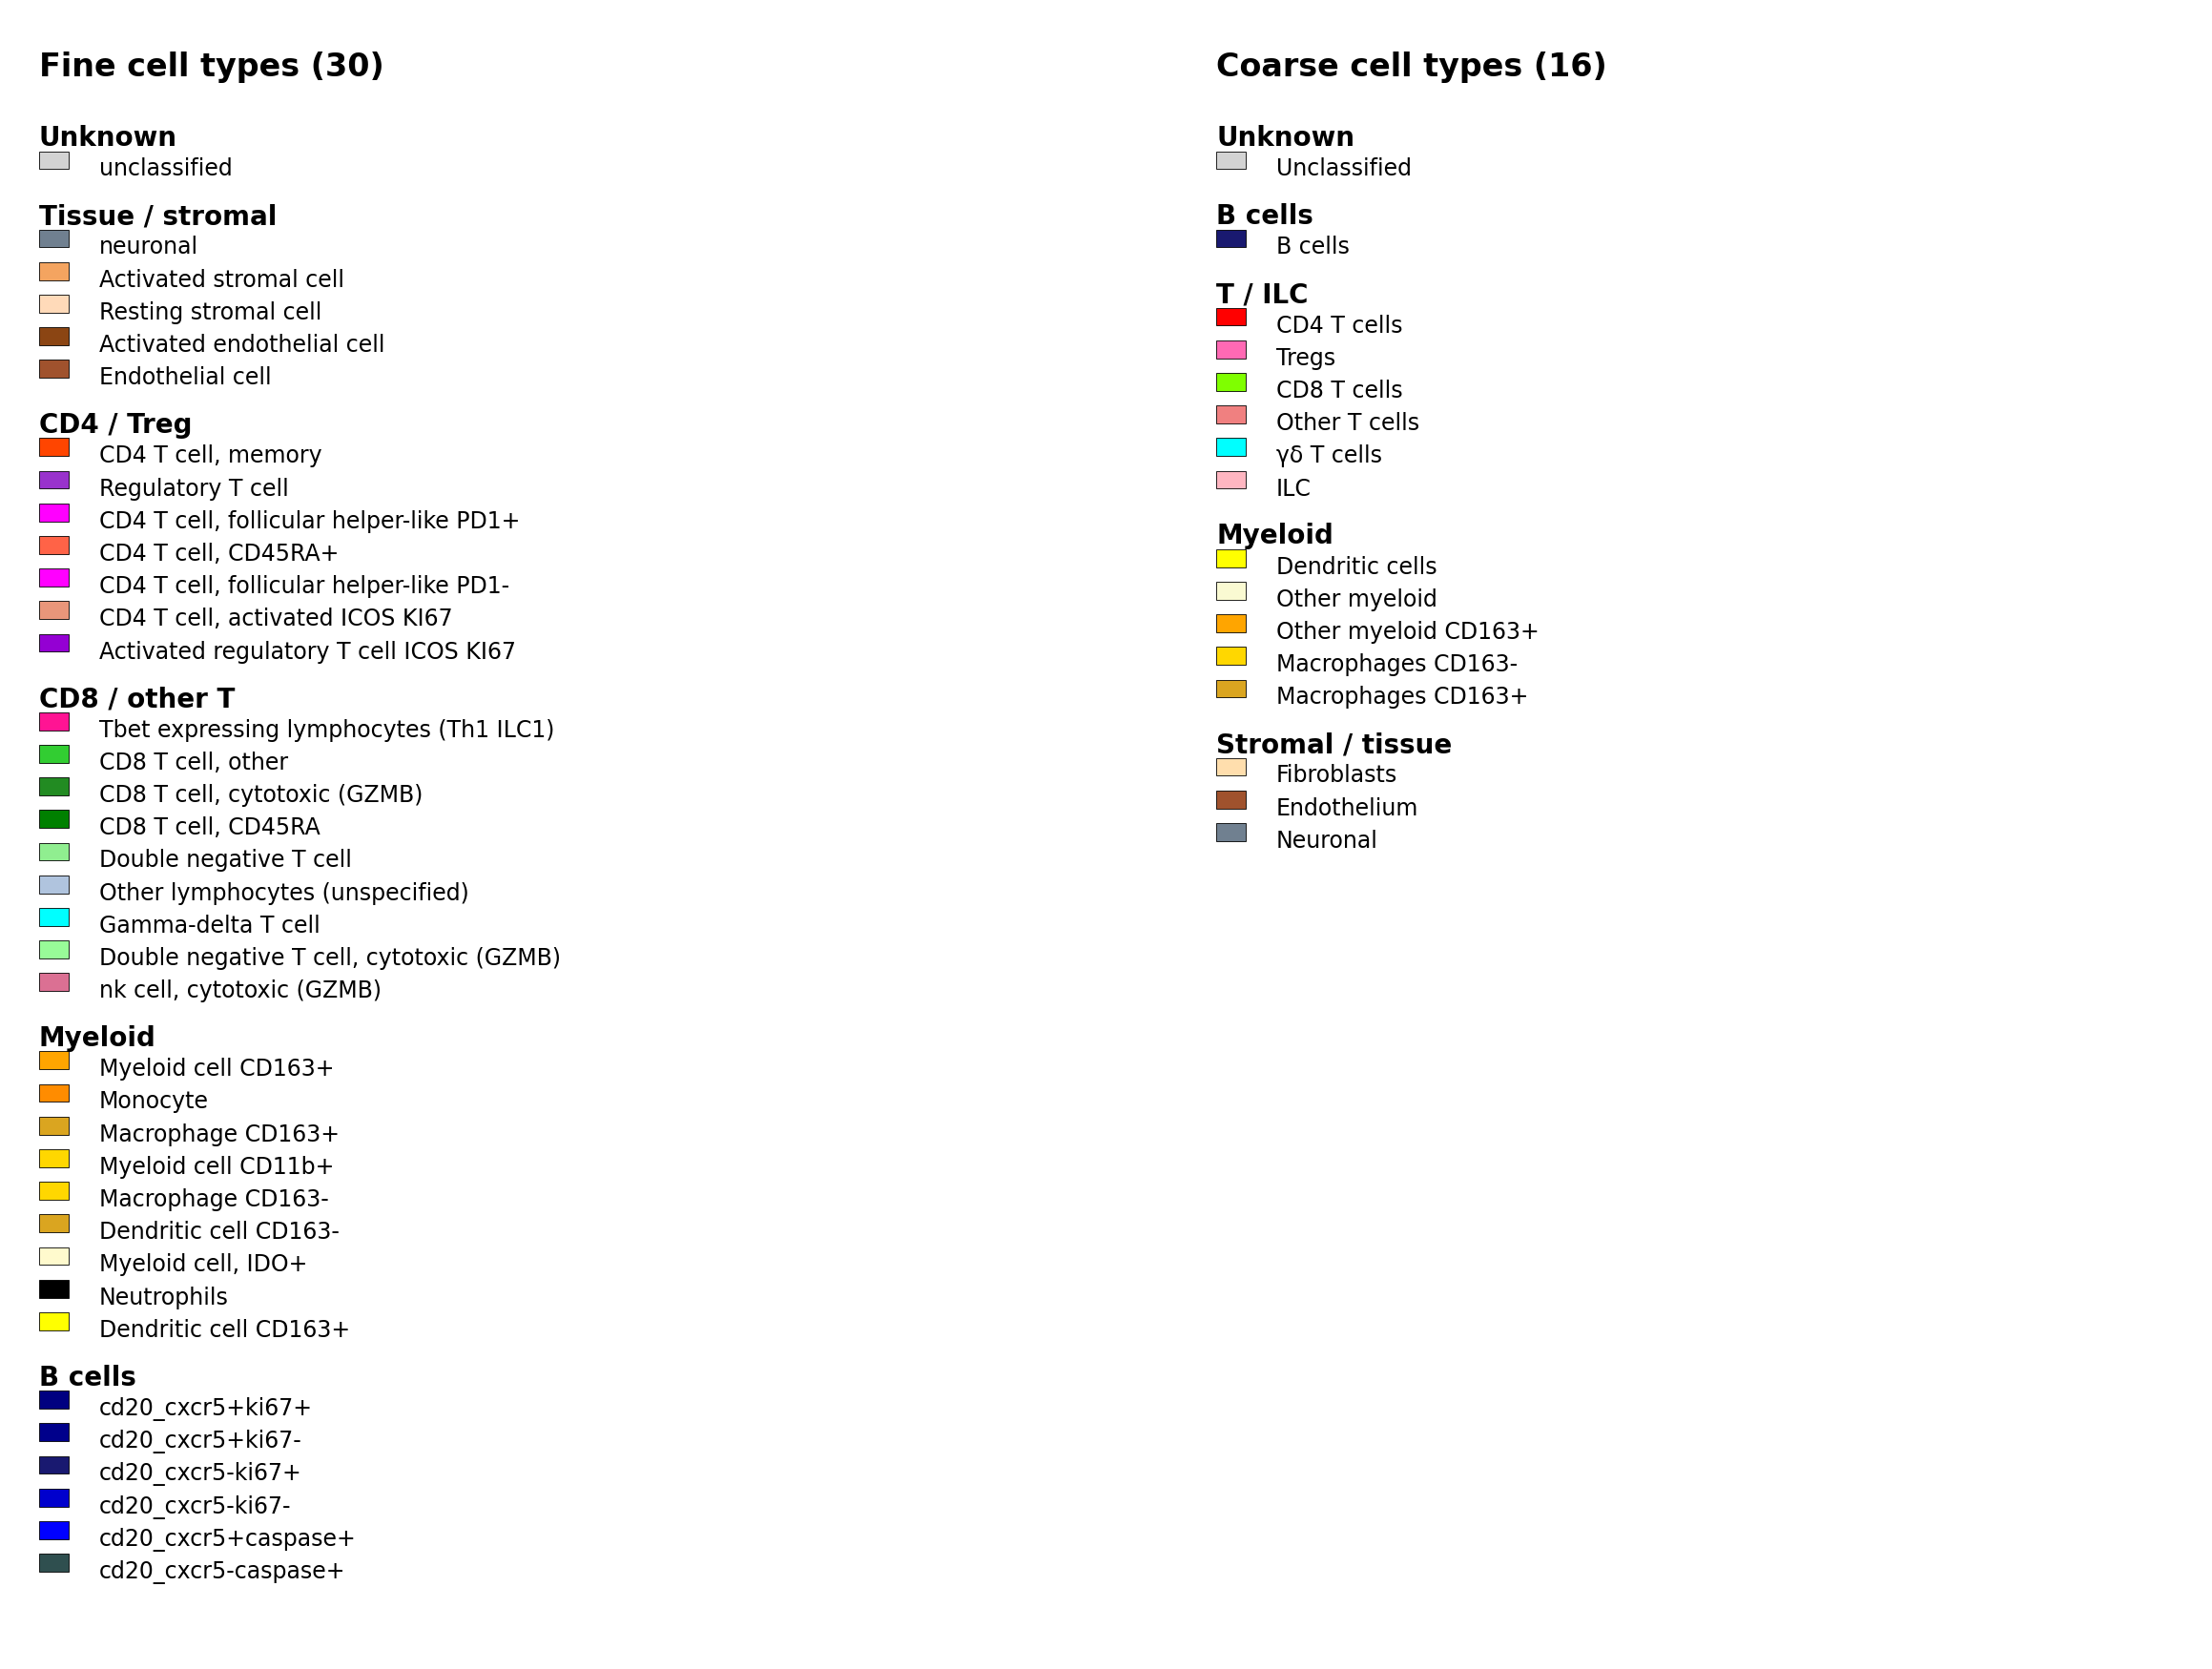

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from dlbcl.phenotype_labels import PHENOTYPE_30_GROUPS as groups_30

cm30 = read_celltype_colormap_30(adata)
cm16 = adata.uns["celltype_colormap_16"].copy()

groups_16 = {
    "Unknown": ["unclassified"],
    "B cells": ["b cells"],
    "T / ILC": [
        "t cells (cd4)",
        "t cells (foxp3)",
        "t cells (cd8)",
        "t cells (other)",
        "t cells (tcrgd)",
        "ILC",
    ],
    "Myeloid": [
        "dendritic cell (cd11c)",
        "myeloid (other)",
        "myeloid (other cd163)",
        "macrophage (cd68)",
        "macrophage (cd68 cd163)",
    ],
    "Stromal / tissue": [
        "fibroblasts",
        "endothelium",
        "neuronal",
    ],
}

pretty_labels_16 = {
    "ILC": "ILC",
    "b cells": "B cells",
    "dendritic cell (cd11c)": "Dendritic cells",
    "endothelium": "Endothelium",
    "fibroblasts": "Fibroblasts",
    "macrophage (cd68 cd163)": "Macrophages CD163+",
    "macrophage (cd68)": "Macrophages CD163-",
    "myeloid (other cd163)": "Other myeloid CD163+",
    "myeloid (other)": "Other myeloid",
    "neuronal": "Neuronal",
    "t cells (cd4)": "CD4 T cells",
    "t cells (cd8)": "CD8 T cells",
    "t cells (foxp3)": "Tregs",
    "t cells (other)": "Other T cells",
    "t cells (tcrgd)": "γδ T cells",
    "unclassified": "Unclassified",
}

pretty_labels_30 = {label: label for labels in groups_30.values() for label in labels}


def draw_grouped_legend(ax, cmap_dict, groups, pretty_labels, title):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    x_box = 0.02
    x_text = 0.08
    y = 0.98

    ax.text(x_box, y, title, fontsize=12, fontweight="bold", va="top")
    y -= 0.045

    row_h = 0.020
    group_gap = 0.008
    box_w = 0.03
    box_h = 0.011

    for group_name, cats in groups.items():
        cats_present = [c for c in cats if c in cmap_dict]
        if not cats_present:
            continue

        ax.text(x_box, y, group_name, fontsize=10, fontweight="bold", va="top")
        y -= row_h

        for cat in cats_present:
            color = cmap_dict[cat]
            label = pretty_labels.get(cat, cat)

            ax.add_patch(Rectangle((x_box, y - box_h + 0.004), box_w, box_h,
                                   facecolor=color, edgecolor="black", linewidth=0.3))
            ax.text(x_text, y, label, fontsize=8.5, va="top")
            y -= row_h

        y -= group_gap

fig, axes = plt.subplots(1, 2, figsize=(12, 9), dpi=200)
draw_grouped_legend(axes[0], cm30, groups_30, pretty_labels_30, "Fine cell types (30)")
draw_grouped_legend(axes[1], cm16, groups_16, pretty_labels_16, "Coarse cell types (16)")

plt.subplots_adjust(wspace=0.18, left=0.03, right=0.98, top=0.98, bottom=0.03)

out_png = str(FIG_DIR / "universal_celltype_legend_biological_order.png")
out_svg = str(FIG_DIR / "universal_celltype_legend_biological_order.svg")

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_svg, bbox_inches="tight")
plt.show()


## Fig 3D–O — Transcriptome programs by immune archetype

Patient-level bulk expression summaries across immune archetypes (`abundance_cluster_30`).

| Panel | Description |
|-------|-------------|
| 3D | Top class-driving gene heatmap |
| 3E–L | Immune and T-helper module scores (cytotoxicity, exhaustion, senescence, Tfh, Th1/2/17, Treg) |
| 3M | EcoTyper B-cell states by archetype |
| 3O | GSEA dotplot — Hallmark (primary); ImmuneSigDB C7 (alternative panel) |

Archetype labels: embedded `adata.uns['case_classifications']['abundance_cluster_30_label']`.

**Data:** `data/DLBCL_location_2026.h5ad` — set `DLBCL_DATA_DIR` to override the data root.

In [6]:
# Transcriptome panels use the discovery patient subset.
import gc

mask = (
    adata_full.obs["patient_id"].isin(PATIENT_SUBSET)
    & (adata_full.obs["filtering_status"] == "Unfiltered")
)
adata = adata_full[mask].copy()
gc.collect()
print(f"Transcriptome cells: {adata.n_obs:,} | patients: {adata.obs['patient_id'].nunique()}")


Transcriptome cells: 1,192,844 | patients: 64


## Differential expression by immune archetype

In [7]:
# ============================================================
# CELL 1 — Setup, alignment, labels
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, leaves_list

plt.rcParams["svg.fonttype"] = "none"

OUTDIR = Path(FIG_DIR) / ("de_gene_expression")
OUTDIR.mkdir(parents=True, exist_ok=True)

CLASS_COL = "abundance_cluster_30"

cluster_name_map = {
    1: "low immune",
    2: "cytotoxic predominant",
    3: "complex immune",
}

cluster_order_raw = [1, 2, 3]
cluster_order = [cluster_name_map[k] for k in cluster_order_raw]

CLASS_COLORS = {
    "low immune": "#d62728",
    "cytotoxic predominant": "#1f77b4",
    "complex immune": "#2ca02c",
}

expr = adata.uns["gene_expression"].copy()          # genes x patients
meta = adata.uns["case_classifications"].copy()

if "patient_id" not in meta.columns:
    meta["patient_id"] = meta.index.astype(str)

meta["patient_id"] = meta["patient_id"].astype(str).str.strip()
expr.columns = expr.columns.astype(str).str.strip()

common = pd.Index(expr.columns).intersection(meta["patient_id"])

X = expr.loc[:, common].T.copy()  # patients x genes
meta_aligned = (
    meta.drop_duplicates("patient_id")
        .set_index("patient_id")
        .loc[common]
        .copy()
)

y_raw = meta_aligned[CLASS_COL]

# map 1/2/3 to readable names
def map_cluster(x):
    if pd.isna(x):
        return np.nan
    try:
        xi = int(float(x))
        return cluster_name_map.get(xi, str(x).strip())
    except Exception:
        return str(x).strip()

y = y_raw.map(map_cluster)

mask = y.notna() & y.isin(cluster_order)
X = X.loc[mask].copy()
y = y.loc[mask].copy()
meta_de = meta_aligned.loc[mask].copy()
meta_de["class_label"] = y

# clean genes
X = X.apply(pd.to_numeric, errors="coerce")
X = X.loc[:, X.notna().any(axis=0)]
X = X.loc[:, X.var(axis=0, ddof=1).fillna(0) > 0]

# optional: drop genes with too much missingness
MIN_NONNA_FRAC = 0.8
keep = X.notna().mean(axis=0) >= MIN_NONNA_FRAC
X = X.loc[:, keep].copy()

# impute remaining missing values by gene median
X = X.apply(lambda s: s.fillna(s.median()), axis=0)

print("X shape:", X.shape)
print("Class counts:")
print(y.value_counts().reindex(cluster_order))

X shape: (64, 797)
Class counts:
abundance_cluster_30
low immune               29
cytotoxic predominant    15
complex immune           20
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL 2 — Global 3-class test: one-way ANOVA / F-test
# ============================================================

global_rows = []

for gene in X.columns:
    vals_by_group = [
        X.loc[y == cls, gene].values
        for cls in cluster_order
    ]

    # skip genes with too few samples in any class
    if any(len(v) < 2 for v in vals_by_group):
        continue

    f_stat, p_val = stats.f_oneway(*vals_by_group)

    means = {
        f"mean_{cls}": np.mean(X.loc[y == cls, gene])
        for cls in cluster_order
    }

    global_rows.append({
        "gene": gene,
        "F": f_stat,
        "p": p_val,
        **means,
        "range_mean": max(means.values()) - min(means.values()),
        "std_mean": np.std(list(means.values()), ddof=1),
    })

global_de = pd.DataFrame(global_rows)

global_de["q"] = multipletests(global_de["p"], method="fdr_bh")[1]
global_de = global_de.sort_values(["q", "p", "range_mean"], ascending=[True, True, False])

global_de.to_csv(OUTDIR / "global_3class_anova_gene_expression.csv", index=False)

display(global_de.head(20))
print("Global q<0.05:", (global_de["q"] < 0.05).sum())
print("Global q<0.10:", (global_de["q"] < 0.10).sum())

,gene,F,p,mean_low immune,mean_cytotoxic predominant,mean_complex immune,range_mean,std_mean,q
420,KLRC2,24.898790,1.242758e-08,-3.859728,-1.811505,-3.879998,2.068494,1.188437,0.000010
586,PRKCH,18.284144,6.006825e-07,-1.455766,-0.140722,-0.153648,1.315043,0.755537,0.000239
8,AEBP1,17.475998,9.997987e-07,-0.298494,-0.520930,1.156306,1.677236,0.910956,0.000256
671,SLFN5,17.085500,1.282829e-06,-0.699427,0.187336,0.620026,1.319453,0.672623,0.000256
291,GBP5,16.676794,1.668891e-06,-0.120025,1.795740,0.604398,1.915764,0.967319,0.000266
651,SH2D1A,16.018950,2.561138e-06,-3.093806,-1.419782,-1.860754,1.674024,0.867682,0.000340
105,CCL5,15.714234,3.129569e-06,0.160659,1.550913,1.295521,1.390254,0.740038,0.000356
389,IRF1,15.041546,4.894496e-06,-1.967281,-0.989291,-0.940407,1.026874,0.579271,0.000389
448,LY6E,14.880958,5.451280e-06,-1.226883,-0.450440,-0.109204,1.117680,0.572788,0.000389
724,TMEM140,14.804028,5.740797e-06,-1.730404,-0.990104,-0.942891,0.787513,0.441673,0.000389


Global q<0.05: 256
Global q<0.10: 334


In [9]:
# ============================================================
# CELL 3 — Pairwise DE: all 1-vs-1 contrasts
# ============================================================

PAIRWISE_Q_TH = 0.05
PAIRWISE_LFC_TH = 0.25  # adjust depending on scale of expression matrix

def run_pairwise_de(X, y, class_a, class_b):
    rows = []

    Xa = X.loc[y == class_a]
    Xb = X.loc[y == class_b]

    for gene in X.columns:
        va = Xa[gene].values
        vb = Xb[gene].values

        t_stat, p_val = stats.ttest_ind(va, vb, equal_var=False, nan_policy="omit")

        mean_a = np.nanmean(va)
        mean_b = np.nanmean(vb)
        diff = mean_a - mean_b

        rows.append({
            "gene": gene,
            "contrast": f"{class_a}__vs__{class_b}",
            "class_a": class_a,
            "class_b": class_b,
            "mean_a": mean_a,
            "mean_b": mean_b,
            "diff": diff,
            "logFC_like": diff,
            "t": t_stat,
            "p": p_val,
            "n_a": len(va),
            "n_b": len(vb),
        })

    df = pd.DataFrame(rows)
    df["q"] = multipletests(df["p"].fillna(1), method="fdr_bh")[1]
    df["direction"] = np.where(df["diff"] > 0, "up_in_class_a", "up_in_class_b")
    df["significant"] = (df["q"] < PAIRWISE_Q_TH) & (df["diff"].abs() >= PAIRWISE_LFC_TH)
    return df.sort_values(["q", "p", "diff"], ascending=[True, True, False])

pairwise_results = []

for i, class_a in enumerate(cluster_order):
    for class_b in cluster_order[i+1:]:
        df = run_pairwise_de(X, y, class_a, class_b)
        pairwise_results.append(df)
        safe_name = f"{class_a}_vs_{class_b}".replace(" ", "_")
        df.to_csv(OUTDIR / f"pairwise_DE_{safe_name}.csv", index=False)

pairwise_de = pd.concat(pairwise_results, ignore_index=True)
pairwise_de.to_csv(OUTDIR / "pairwise_DE_all_contrasts.csv", index=False)

display(pairwise_de.head(20))

summary_pairwise = (
    pairwise_de
    .groupby("contrast")
    .agg(
        n_genes=("gene", "size"),
        n_sig=("significant", "sum"),
        n_q005=("q", lambda s: (s < 0.05).sum()),
        n_q010=("q", lambda s: (s < 0.10).sum()),
    )
    .reset_index()
)

display(summary_pairwise)
summary_pairwise.to_csv(OUTDIR / "pairwise_DE_summary_counts.csv", index=False)

,gene,contrast,class_a,class_b,mean_a,mean_b,diff,logFC_like,t,p,n_a,n_b,q,direction,significant
0,KLRC2,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,-3.859728,-1.811505,-2.048223,-2.048223,-6.723443,1.711620e-07,29,15,0.000136,up_in_class_b,True
1,GBP5,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,-0.120025,1.795740,-1.915764,-1.915764,-5.849651,1.068365e-06,29,15,0.000413,up_in_class_b,True
2,RNF213,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,1.584907,2.909933,-1.325026,-1.325026,-5.541277,1.814670e-06,29,15,0.000413,up_in_class_b,True
3,SH2D1A,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,-3.093806,-1.419782,-1.674024,-1.674024,-5.544731,2.072439e-06,29,15,0.000413,up_in_class_b,True
4,IFNG,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,-3.027172,-1.579157,-1.448014,-1.448014,-5.568920,3.286382e-06,29,15,0.000524,up_in_class_b,True
5,CCL5,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,0.160659,1.550913,-1.390254,-1.390254,-5.131230,8.685354e-06,29,15,0.001129,up_in_class_b,True
6,HAVCR2,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,-0.751256,0.188339,-0.939595,-0.939595,-5.074564,9.916429e-06,29,15,0.001129,up_in_class_b,True
7,EOMES,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,-1.571540,0.127453,-1.698993,-1.698993,-4.992673,1.519822e-05,29,15,0.001334,up_in_class_b,True
8,SERPINA1,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,-0.876672,0.501279,-1.377952,-1.377952,-5.090372,1.627585e-05,29,15,0.001334,up_in_class_b,True
9,FCGR1B,low immune__vs__cytotoxic predominant,low immune,cytotoxic predominant,-3.951606,-2.362025,-1.589581,-1.589581,-5.086752,1.674909e-05,29,15,0.001334,up_in_class_b,True


,contrast,n_genes,n_sig,n_q005,n_q010
0,cytotoxic predominant__vs__complex immune,797,80,80,151
1,low immune__vs__complex immune,797,199,199,282
2,low immune__vs__cytotoxic predominant,797,89,89,139


In [10]:
# ============================================================
# CELL 4 — Class-driving UP/DOWN genes
# ============================================================

GLOBAL_Q_TH = 0.10
DRIVER_Q_TH = 0.05
DRIVER_DIFF_TH = 0.25

# helper: get signed effect target - comparator from pairwise table
def get_signed_pairwise_effect(pairwise_de, target, comparator):
    # direct contrast target vs comparator
    direct = pairwise_de[
        (pairwise_de["class_a"] == target) &
        (pairwise_de["class_b"] == comparator)
    ][["gene", "diff", "p", "q"]].copy()

    if not direct.empty:
        direct = direct.rename(columns={
            "diff": f"diff_{target}_minus_{comparator}",
            "p": f"p_{target}_minus_{comparator}",
            "q": f"q_{target}_minus_{comparator}",
        })
        return direct

    # reverse contrast comparator vs target
    rev = pairwise_de[
        (pairwise_de["class_a"] == comparator) &
        (pairwise_de["class_b"] == target)
    ][["gene", "diff", "p", "q"]].copy()

    rev[f"diff_{target}_minus_{comparator}"] = -rev["diff"]
    rev = rev.rename(columns={
        "p": f"p_{target}_minus_{comparator}",
        "q": f"q_{target}_minus_{comparator}",
    })

    return rev[[
        "gene",
        f"diff_{target}_minus_{comparator}",
        f"p_{target}_minus_{comparator}",
        f"q_{target}_minus_{comparator}",
    ]]

driver_tables = []

global_keep = global_de[["gene", "F", "p", "q", "range_mean", "std_mean"]].rename(
    columns={"p": "global_p", "q": "global_q"}
)

for target in cluster_order:
    others = [c for c in cluster_order if c != target]

    tmp = global_keep.copy()

    for comp in others:
        eff = get_signed_pairwise_effect(pairwise_de, target, comp)
        tmp = tmp.merge(eff, on="gene", how="left")

    diff_cols = [f"diff_{target}_minus_{c}" for c in others]
    q_cols = [f"q_{target}_minus_{c}" for c in others]

    tmp["target_class"] = target

    # UP: target greater than both others
    tmp["min_diff_vs_others"] = tmp[diff_cols].min(axis=1)
    tmp["max_diff_vs_others"] = tmp[diff_cols].max(axis=1)
    tmp["max_pairwise_q"] = tmp[q_cols].max(axis=1)

    tmp["driver_direction"] = np.select(
        [
            (tmp["min_diff_vs_others"] >= DRIVER_DIFF_TH) &
            (tmp["max_pairwise_q"] < DRIVER_Q_TH) &
            (tmp["global_q"] < GLOBAL_Q_TH),

            (tmp["max_diff_vs_others"] <= -DRIVER_DIFF_TH) &
            (tmp["max_pairwise_q"] < DRIVER_Q_TH) &
            (tmp["global_q"] < GLOBAL_Q_TH),
        ],
        ["UP", "DOWN"],
        default="not_driver"
    )

    # conservative ranking score
    tmp["driver_score"] = np.where(
        tmp["driver_direction"] == "UP",
        tmp["min_diff_vs_others"] * -np.log10(tmp["max_pairwise_q"].clip(lower=1e-300)),
        np.where(
            tmp["driver_direction"] == "DOWN",
            abs(tmp["max_diff_vs_others"]) * -np.log10(tmp["max_pairwise_q"].clip(lower=1e-300)),
            np.nan
        )
    )

    driver_tables.append(tmp)

class_drivers = pd.concat(driver_tables, ignore_index=True)

class_drivers = class_drivers.sort_values(
    ["target_class", "driver_direction", "driver_score"],
    ascending=[True, True, False]
)

class_drivers.to_csv(OUTDIR / "class_driving_UP_DOWN_genes.csv", index=False)

display(
    class_drivers[class_drivers["driver_direction"] != "not_driver"]
    .groupby(["target_class", "driver_direction"])
    .size()
    .reset_index(name="n")
)

display(class_drivers[class_drivers["driver_direction"] != "not_driver"].head(30))

,target_class,driver_direction,n
0,complex immune,DOWN,8
1,complex immune,UP,25
2,cytotoxic predominant,DOWN,2
3,cytotoxic predominant,UP,17
4,low immune,DOWN,37


,gene,F,global_p,global_q,range_mean,std_mean,diff_low immune_minus_cytotoxic predominant,p_low immune_minus_cytotoxic predominant,q_low immune_minus_cytotoxic predominant,diff_low immune_minus_complex immune,...,q_cytotoxic predominant_minus_low immune,diff_cytotoxic predominant_minus_complex immune,p_cytotoxic predominant_minus_complex immune,q_cytotoxic predominant_minus_complex immune,diff_complex immune_minus_low immune,p_complex immune_minus_low immune,q_complex immune_minus_low immune,diff_complex immune_minus_cytotoxic predominant,p_complex immune_minus_cytotoxic predominant,q_complex immune_minus_cytotoxic predominant
1711,ACTG2,6.933756,1.934689e-03,0.013013,2.196691,1.221883,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-2.025657,0.001016,0.013270,-2.196691,0.001067,0.020961
1612,GOT2,12.187060,3.524599e-05,0.001423,1.109994,0.629402,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-1.109994,0.000022,0.001632,-1.069173,0.000180,0.007977
1720,CDCA7L,6.454077,2.867101e-03,0.017993,0.897793,0.516166,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.890212,0.002173,0.018044,-0.897793,0.001399,0.024243
1784,RASGRF1,5.352446,7.216424e-03,0.030113,1.045705,0.582252,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-1.045705,0.006235,0.031650,-0.966618,0.002569,0.034129
1797,ARHGAP17,5.141427,8.640029e-03,0.033755,0.884989,0.502210,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.853884,0.004715,0.026816,-0.884989,0.000134,0.006485
1714,ZFAT,6.866821,2.043232e-03,0.013449,0.897108,0.506312,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.855314,0.000610,0.010349,-0.897108,0.003727,0.044187
1716,LYAR,6.806151,2.147047e-03,0.013912,0.763397,0.434599,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.763397,0.000827,0.011951,-0.741625,0.004851,0.049568
1691,CCNE1,7.456709,1.267198e-03,0.010306,0.738056,0.377228,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.504517,0.004797,0.026816,-0.738056,0.000069,0.006280
1625,TMEM119,10.843468,9.348344e-05,0.002328,2.032383,1.158127,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.978398,0.000151,0.004626,2.032383,0.000024,0.003807
1596,AEBP1,17.475998,9.997987e-07,0.000256,1.677236,0.910956,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.454800,0.000024,0.001632,1.677236,0.000005,0.001396


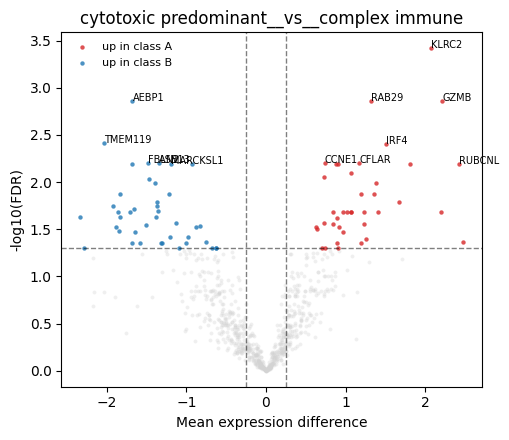

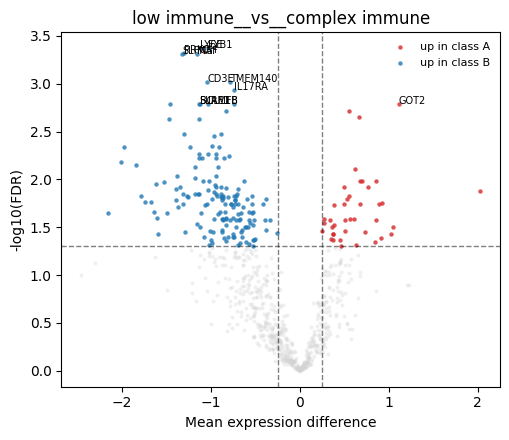

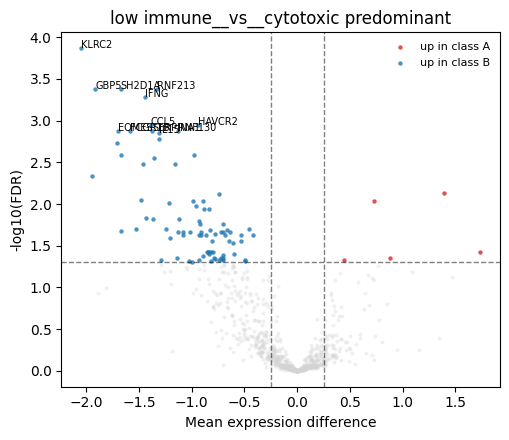

In [11]:
# ============================================================
# CELL 5 — Volcano plots
# ============================================================

def volcano_plot(df, contrast_name, out_prefix, q_th=0.05, diff_th=0.25, top_n_label=12):
    plot_df = df.copy()
    plot_df["minus_log10_q"] = -np.log10(plot_df["q"].clip(lower=1e-300))

    fig, ax = plt.subplots(figsize=(5.2, 4.5))

    sig = (plot_df["q"] < q_th) & (plot_df["diff"].abs() >= diff_th)

    ax.scatter(
        plot_df.loc[~sig, "diff"],
        plot_df.loc[~sig, "minus_log10_q"],
        s=8,
        alpha=0.35,
        linewidths=0,
        color="lightgray",
    )

    ax.scatter(
        plot_df.loc[sig & (plot_df["diff"] > 0), "diff"],
        plot_df.loc[sig & (plot_df["diff"] > 0), "minus_log10_q"],
        s=10,
        alpha=0.8,
        linewidths=0,
        color="#d62728",
        label="up in class A",
    )

    ax.scatter(
        plot_df.loc[sig & (plot_df["diff"] < 0), "diff"],
        plot_df.loc[sig & (plot_df["diff"] < 0), "minus_log10_q"],
        s=10,
        alpha=0.8,
        linewidths=0,
        color="#1f77b4",
        label="up in class B",
    )

    ax.axvline(diff_th, linestyle="--", linewidth=1, color="black", alpha=0.5)
    ax.axvline(-diff_th, linestyle="--", linewidth=1, color="black", alpha=0.5)
    ax.axhline(-np.log10(q_th), linestyle="--", linewidth=1, color="black", alpha=0.5)

    label_df = plot_df[sig].sort_values("q").head(top_n_label)
    for _, row in label_df.iterrows():
        ax.text(row["diff"], row["minus_log10_q"], row["gene"], fontsize=7)

    ax.set_title(contrast_name)
    ax.set_xlabel("Mean expression difference")
    ax.set_ylabel("-log10(FDR)")
    ax.legend(frameon=False, fontsize=8)

    fig.tight_layout()
    fig.savefig(OUTDIR / f"{out_prefix}.png", dpi=300)
    fig.savefig(OUTDIR / f"{out_prefix}.svg")
    plt.show()

for contrast, df in pairwise_de.groupby("contrast"):
    out_prefix = "volcano_" + contrast.replace(" ", "_").replace("__vs__", "_vs_")
    volcano_plot(df, contrast, out_prefix, q_th=PAIRWISE_Q_TH, diff_th=PAIRWISE_LFC_TH)

In [12]:
# ============================================================
# CELL 6 — Compact top-driver summary tables
# ============================================================

TOP_N = 30

top_driver_rows = []

for cls in cluster_order:
    for direction in ["UP", "DOWN"]:
        sub = (
            class_drivers[
                (class_drivers["target_class"] == cls) &
                (class_drivers["driver_direction"] == direction)
            ]
            .sort_values("driver_score", ascending=False)
            .head(TOP_N)
            .copy()
        )
        sub["rank"] = np.arange(1, len(sub) + 1)
        top_driver_rows.append(sub)

top_drivers = pd.concat(top_driver_rows, ignore_index=True)

cols_first = [
    "target_class",
    "driver_direction",
    "rank",
    "gene",
    "driver_score",
    "global_q",
    "max_pairwise_q",
    "min_diff_vs_others",
    "max_diff_vs_others",
]

top_drivers = top_drivers[cols_first + [c for c in top_drivers.columns if c not in cols_first]]
top_drivers.to_csv(OUTDIR / "top_class_drivers_ranked.csv", index=False)
log_saved(write_supplementary_table(top_drivers, REPO_ROOT, "fig3D_top_class_drivers_ranked"), REPO_ROOT)

display(top_drivers[cols_first].head(60))

Saved: data/supplementary/fig3/fig3D_top_class_drivers_ranked.csv


,target_class,driver_direction,rank,gene,driver_score,global_q,max_pairwise_q,min_diff_vs_others,max_diff_vs_others
0,low immune,DOWN,1,PRKCH,3.615822,0.000239,0.001672,-1.315043,-1.302118
1,low immune,DOWN,2,CCL5,2.990509,0.000356,0.002317,-1.390254,-1.134862
2,low immune,DOWN,3,SH2D1A,2.878876,0.000340,0.004626,-1.674024,-1.233053
3,low immune,DOWN,4,IRF1,2.530362,0.000389,0.002586,-1.026874,-0.977990
4,low immune,DOWN,5,CD3E,2.012530,0.000389,0.009288,-1.039174,-0.990374
5,low immune,DOWN,6,SLFN5,1.725432,0.000256,0.011330,-1.319453,-0.886764
6,low immune,DOWN,7,CD2,1.721312,0.003124,0.021379,-1.084591,-1.030724
7,low immune,DOWN,8,CXCL9,1.712304,0.012954,0.047400,-1.386681,-1.293068
8,low immune,DOWN,9,SLC2A3,1.594223,0.003124,0.015113,-1.121259,-0.875628
9,low immune,DOWN,10,SERPING1,1.568644,0.004766,0.016338,-0.931866,-0.877909


### Fig 3D — top class-driving gene heatmap

n heatmap genes: 89
Saved: data/supplementary/fig3/fig3D_heatmap_zscores.csv


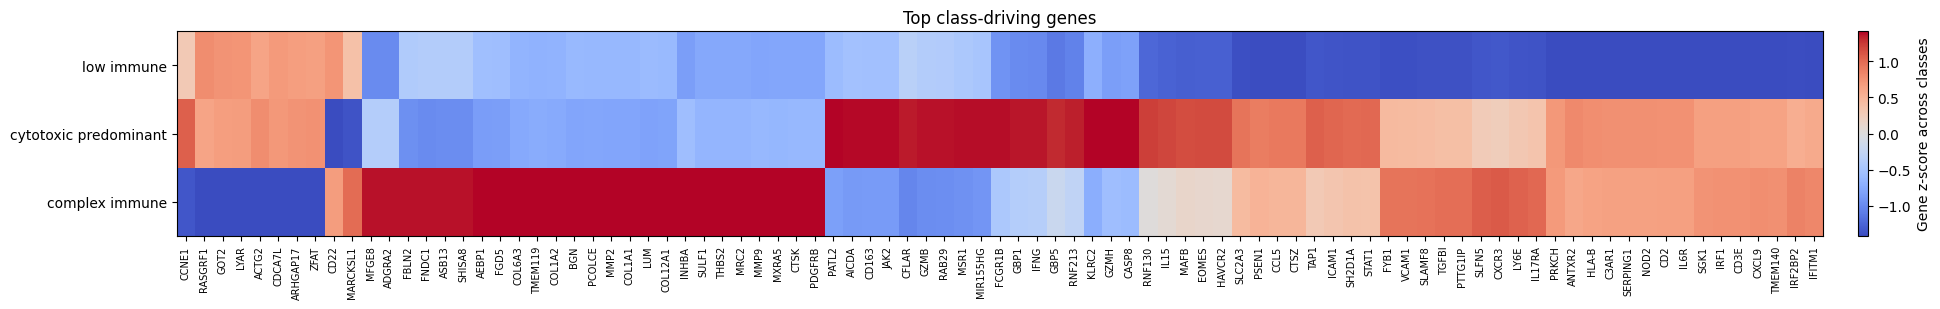

In [13]:
# ============================================================
# CELL 7 — Heatmap of top class-driving genes
# ============================================================

TOP_PER_CLASS_DIRECTION = 50

genes_for_heatmap = []

for cls in cluster_order:
    for direction in ["UP", "DOWN"]:
        genes = (
            class_drivers[
                (class_drivers["target_class"] == cls) &
                (class_drivers["driver_direction"] == direction)
            ]
            .sort_values("driver_score", ascending=False)
            .head(TOP_PER_CLASS_DIRECTION)["gene"]
            .tolist()
        )
        genes_for_heatmap.extend(genes)

genes_for_heatmap = list(dict.fromkeys(genes_for_heatmap))

print("n heatmap genes:", len(genes_for_heatmap))

# class-level mean expression
mean_expr = pd.DataFrame({
    cls: X.loc[y == cls, genes_for_heatmap].mean(axis=0)
    for cls in cluster_order
}).T

# z-score per gene across classes
zmat = pd.DataFrame(
    StandardScaler(with_mean=True, with_std=True).fit_transform(mean_expr),
    index=mean_expr.index,
    columns=mean_expr.columns,
)

# cluster genes only
if zmat.shape[1] > 1:
    gene_order = zmat.columns[leaves_list(linkage(zmat.T, method="average"))]
else:
    gene_order = zmat.columns

zmat = zmat.loc[cluster_order, gene_order]
log_saved(write_supplementary_table(zmat, REPO_ROOT, "fig3D_heatmap_zscores", index=True), REPO_ROOT)

fig, ax = plt.subplots(figsize=(max(8, 0.22 * zmat.shape[1]), 3.2))

im = ax.imshow(zmat.values, aspect="auto", interpolation="nearest", cmap="vlag" if False else "coolwarm")

ax.set_yticks(np.arange(len(zmat.index)))
ax.set_yticklabels(zmat.index)

ax.set_xticks(np.arange(len(zmat.columns)))
ax.set_xticklabels(zmat.columns, rotation=90, fontsize=7)

ax.set_title("Top class-driving genes")
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Gene z-score across classes")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3D_top_class_drivers_heatmap.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "fig3D_top_class_drivers_heatmap.svg", bbox_inches="tight")
fig.savefig(OUTDIR / "heatmap_top_class_driving_genes.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTDIR / "heatmap_top_class_driving_genes.svg", bbox_inches="tight")
plt.show()


In [14]:
# ============================================================
# CELL 8 — Export class-level ranked gene lists for GSEA
# ============================================================

rank_dir = OUTDIR / "gsea_ranked_lists"
rank_dir.mkdir(exist_ok=True)

for cls in cluster_order:
    sub = class_drivers[class_drivers["target_class"] == cls].copy()

    # signed score:
    # positive = high in target class
    # negative = low in target class
    sub["signed_driver_score"] = np.where(
        sub["min_diff_vs_others"] > 0,
        sub["min_diff_vs_others"],
        sub["max_diff_vs_others"]
    ) * -np.log10(sub["max_pairwise_q"].clip(lower=1e-300))

    rnk = (
        sub[["gene", "signed_driver_score"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values("signed_driver_score", ascending=False)
    )

    safe_cls = cls.replace(" ", "_")
    rnk.to_csv(
        rank_dir / f"{safe_cls}_class_driver_prerank.rnk",
        sep="\t",
        index=False,
        header=False
    )

    display(rnk.head(10))

,gene,signed_driver_score
112,RUBCNL,1.102558
20,MEF2B,0.792584
216,AURKB,0.711087
307,SNHG19,0.673383
103,FAM216A,0.621304
155,IRF4,0.498315
312,MS4A1,0.469874
106,RASL11A,0.467979
98,KI67,0.391270
84,MARCKSL1,0.389740


,gene,signed_driver_score
797,KLRC2,6.999657
862,GZMB,2.801167
849,AICDA,2.604855
843,CD163,2.567403
801,GBP5,2.232017
820,RNF213,1.969758
855,GBP1,1.920322
812,IFNG,1.789858
867,MSR1,1.770036
956,SPP1,1.768032


,gene,signed_driver_score
1625,TMEM119,4.619076
1596,AEBP1,4.054940
1708,MMP2,3.516334
1656,COL1A2,3.002486
1627,CTSK,2.864214
1705,MMP9,2.740362
1674,LUM,2.679104
1675,COL1A1,2.648718
1638,BGN,2.621516
1661,FNDC1,2.335612


In [15]:
# ============================================================
# CELL 9 — Final summary report table
# ============================================================

report_rows = []

for cls in cluster_order:
    for direction in ["UP", "DOWN"]:
        sub = class_drivers[
            (class_drivers["target_class"] == cls) &
            (class_drivers["driver_direction"] == direction)
        ].copy()

        top_genes = (
            sub.sort_values("driver_score", ascending=False)
            .head(10)["gene"]
            .tolist()
        )

        report_rows.append({
            "class": cls,
            "direction": direction,
            "n_driver_genes": len(sub),
            "top_10_genes": ", ".join(top_genes),
        })

driver_report = pd.DataFrame(report_rows)
driver_report.to_csv(OUTDIR / "class_driver_summary_report.csv", index=False)

display(driver_report)

,class,direction,n_driver_genes,top_10_genes
0,low immune,UP,0,
1,low immune,DOWN,37,"PRKCH, CCL5, SH2D1A, IRF1, CD3E, SLFN5, CD2, C..."
2,cytotoxic predominant,UP,17,"KLRC2, GZMB, AICDA, CD163, GBP5, RNF213, GBP1,..."
3,cytotoxic predominant,DOWN,2,"CD22, MARCKSL1"
4,complex immune,UP,25,"TMEM119, AEBP1, MMP2, COL1A2, CTSK, MMP9, LUM,..."
5,complex immune,DOWN,8,"ACTG2, GOT2, CDCA7L, RASGRF1, ARHGAP17, ZFAT, ..."


## Fig 3E–L — immune / T-helper module scores

Expression patients: 67
Metadata patients: 64
Overlap patients: 64

Class counts:
cluster_name
low immune               29
cytotoxic predominant    15
complex immune           20
Name: count, dtype: int64

tcell_identity: 6/10 genes present
Missing: ['TRBC2', 'LCK', 'LAT', 'ZAP70']

cytotoxicity: 9/12 genes present
Missing: ['PRF1', 'GZMA', 'KLRD1']

ifng_activation: 11/11 genes present

terminal_exhaustion: 8/10 genes present
Missing: ['TOX2', 'LAYN']

progenitor_exhausted_memory: 2/6 genes present
Missing: ['TCF7', 'SLAMF6', 'LEF1', 'CCR7']

senescence_effector_like: 6/9 genes present
Missing: ['KLRG1', 'B3GAT1', 'PRF1']

Th1_IFNg: 9/13 genes present
Missing: ['STAT4', 'IL12RB1', 'IL12RB2', 'CCR5']

Th17_IL17: 9/11 genes present
Missing: ['KLRB1', 'RORA']

Th2_IL4: 6/10 genes present
Missing: ['IL5', 'IL13', 'IL1RL1', 'PTGDR2']

Tfh_GC_helper: 9/10 genes present
Missing: ['TOX2']

Treg_suppressive: 9/10 genes present
Missing: ['LAYN']


,module,n_requested,n_present,present_genes,missing_genes
0,tcell_identity,10,6,"CD3D, CD3E, CD3G, CD2, TRAC, TRBC1","TRBC2, LCK, LAT, ZAP70"
1,cytotoxicity,12,9,"NKG7, GZMB, GZMH, GNLY, IFNG, CX3CR1, KLRC2, K...","PRF1, GZMA, KLRD1"
2,ifng_activation,11,11,"IFNG, STAT1, IRF1, CXCL9, CXCL10, GBP1, GBP5, ...",
3,terminal_exhaustion,10,8,"PDCD1, HAVCR2, LAG3, TIGIT, CTLA4, TOX, ENTPD1...","TOX2, LAYN"
4,progenitor_exhausted_memory,6,2,"IL7R, CXCR5","TCF7, SLAMF6, LEF1, CCR7"
5,senescence_effector_like,9,6,"CX3CR1, GZMH, FGFBP2, NKG7, TBX21, EOMES","KLRG1, B3GAT1, PRF1"
6,Th1_IFNg,13,9,"TBX21, IFNG, STAT1, CXCR3, CXCL9, CXCL10, CXCL...","STAT4, IL12RB1, IL12RB2, CCR5"
7,Th17_IL17,11,9,"RORC, IL17A, IL17F, IL23R, CCR6, STAT3, IL21, ...","KLRB1, RORA"
8,Th2_IL4,10,6,"GATA3, IL4, CCR4, CCR8, STAT6, MAF","IL5, IL13, IL1RL1, PTGDR2"
9,Tfh_GC_helper,10,9,"CXCR5, BCL6, PDCD1, ICOS, SH2D1A, IL21, CD40LG...",TOX2


Saved: data/supplementary/fig3/fig3E-H_module_scores_long.csv
Saved: data/supplementary/fig3/fig3E-H_module_group_summary.csv


,module,test,statistic,p,q
16,terminal_exhaustion,Kruskal-Wallis,21.821437,0.000018,0.000216
7,Th1_IFNg,Kruskal-Wallis,21.164010,0.000025,0.000216
12,ifng_activation,Kruskal-Wallis,19.049939,0.000073,0.000280
11,cytotoxicity,Kruskal-Wallis,18.807871,0.000082,0.000280
15,tcell_identity,Kruskal-Wallis,18.983493,0.000075,0.000280
0,Cytotoxicity_minus_Exhaustion,Kruskal-Wallis,15.972909,0.000340,0.000963
10,Treg_suppressive,Kruskal-Wallis,14.507047,0.000708,0.001719
3,Tfh_GC_helper,Kruskal-Wallis,13.559443,0.001137,0.002415
14,senescence_effector_like,Kruskal-Wallis,11.097208,0.003893,0.006618
8,Th1_minus_Th2,Kruskal-Wallis,11.135628,0.003819,0.006618


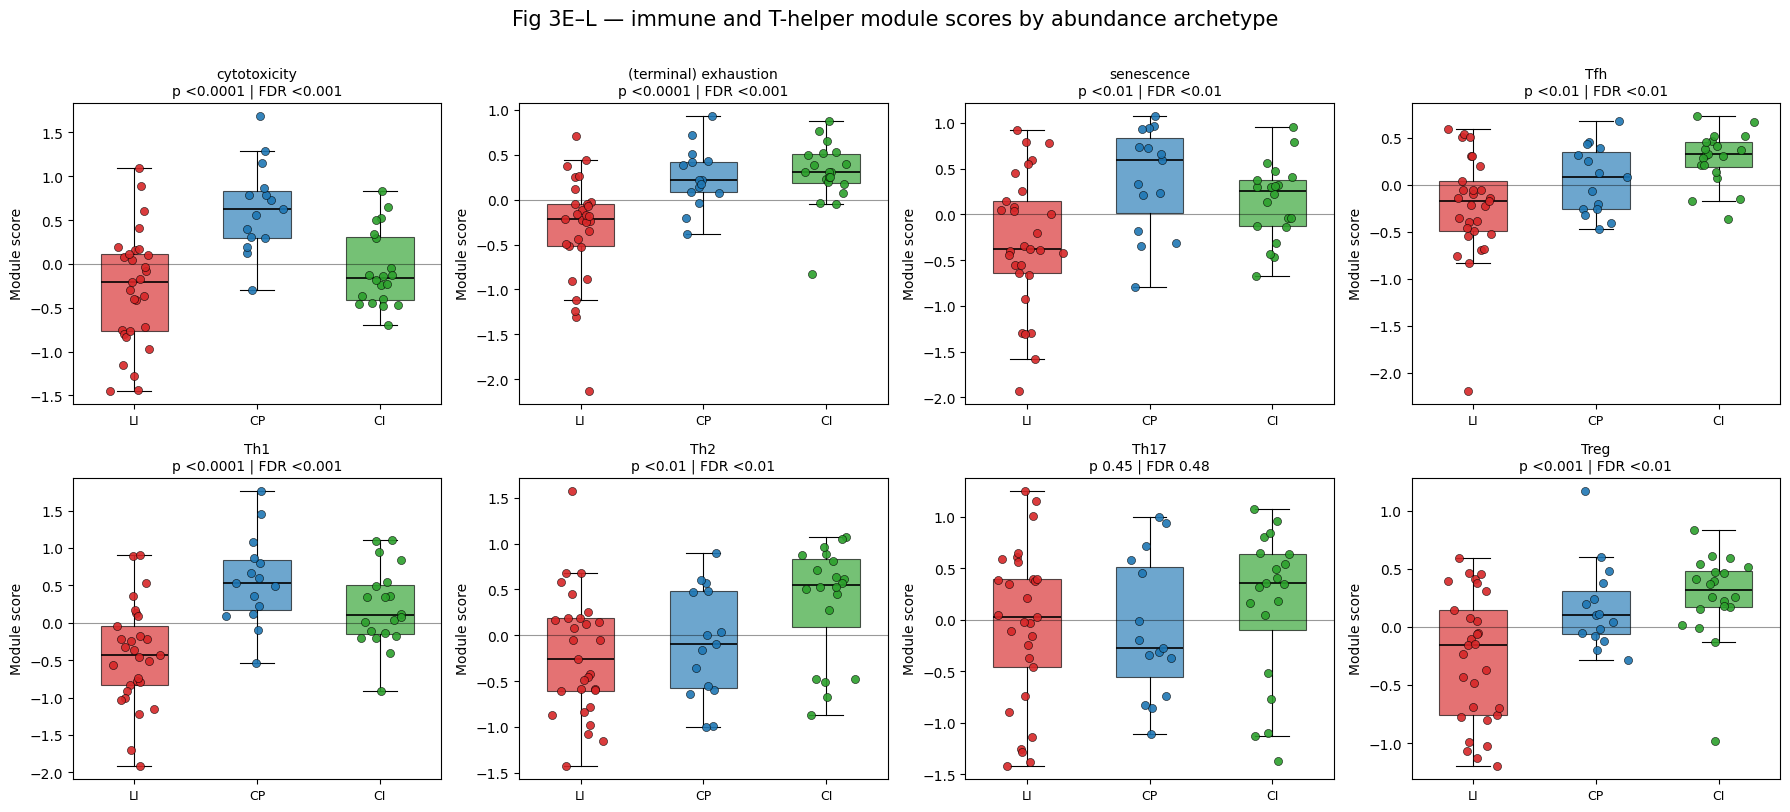

module,patient_id,cluster_name,Tfh_GC_helper,Th17_IL17,Th1_IFNg,Th2_IL4,Treg_suppressive,cytotoxicity,ifng_activation,progenitor_exhausted_memory,senescence_effector_like,tcell_identity,terminal_exhaustion,Th1_minus_Th2,Th17_minus_Th2,Tfh_minus_Treg,TerminalExhaustion_minus_Progenitor,Cytotoxicity_minus_Exhaustion,Inflammatory_Th1Th17_minus_Th2
0,T1,cytotoxic predominant,-0.206946,0.711878,0.804046,0.483589,0.101119,0.622374,0.458784,-1.347135,0.209008,-0.854253,0.388526,0.320458,0.228290,-0.308065,1.735660,0.233848,0.274374
1,T10,low immune,-0.697376,-1.383605,-1.706468,-1.156216,-0.755398,-1.443993,-1.352480,1.272835,-1.576852,-1.171377,-0.024879,-0.550253,-0.227389,0.058021,-1.297715,-1.419113,-0.388821
2,T12,low immune,0.035321,0.396787,-0.045608,-0.423984,0.054494,-0.078823,0.095927,0.561296,-0.396834,-0.876118,0.122368,0.378376,0.820771,-0.019174,-0.438928,-0.201191,0.599573
3,T13,low immune,-0.524735,0.607233,-0.826767,-0.255492,-0.056352,-0.750522,-1.171146,-1.460907,-0.549731,-1.409449,-0.236332,-0.571275,0.862725,-0.468383,1.224574,-0.514189,0.145725
4,T14,low immune,-0.539716,-0.894679,-0.237335,-0.785168,-0.695067,0.194515,-0.023493,-0.164873,-0.342420,-0.579968,-0.442744,0.547833,-0.109511,0.155351,-0.277871,0.637259,0.219161



Saved outputs to:
figures/fig3/immune_thelper_module_scores


In [16]:
# ============================================================
# IMMUNE / T-HELPER MODULE SCORES
# ------------------------------------------------------------
# Input:
#   adata.uns["gene_expression"]      genes x patients
#   adata.uns["case_classifications"] metadata with abundance_cluster_30
#
# Output:
#   - per-patient module scores
#   - derived contrast scores
#   - group summaries
#   - Kruskal-Wallis stats
#   - boxplot + jitter figure
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
OUTDIR = Path(FIG_DIR) / ("immune_thelper_module_scores")
OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["svg.fonttype"] = "none"
ERR_TYPE = "sem"  # "sem" or "sd"
JITTER_WIDTH = 0.10
BOX_WIDTH = 0.55
RANDOM_SEED = 42

cluster_name_map = {
    1: "low immune",
    2: "cytotoxic predominant",
    3: "complex immune",
}

cluster_order = [
    "low immune",
    "cytotoxic predominant",
    "complex immune",
]

short_labels = {
    "low immune": "LI",
    "cytotoxic predominant": "CP",
    "complex immune": "CI",
}

CLASS_COLORS = {
    "low immune": "#d62728",
    "cytotoxic predominant": "#1f77b4",
    "complex immune": "#2ca02c",
}

# ------------------------------------------------------------
# Gene modules
# ------------------------------------------------------------
gene_modules = {
    "tcell_identity": [
        "CD3D", "CD3E", "CD3G", "CD2", "TRAC", "TRBC1",
        "TRBC2", "LCK", "LAT", "ZAP70"
    ],
    "cytotoxicity": [
        "NKG7", "PRF1", "GZMB", "GZMA", "GZMH", "GNLY",
        "IFNG", "CX3CR1", "KLRD1", "KLRC2", "KLRK1", "FGFBP2"
    ],
    "ifng_activation": [
        "IFNG", "STAT1", "IRF1", "CXCL9", "CXCL10", "GBP1",
        "GBP5", "IDO1", "HLA-DRA", "HLA-DRB1", "CD274"
    ],
    "terminal_exhaustion": [
        "PDCD1", "HAVCR2", "LAG3", "TIGIT", "CTLA4",
        "TOX", "TOX2", "ENTPD1", "CXCL13", "LAYN"
    ],
    "progenitor_exhausted_memory": [
        "TCF7", "IL7R", "SLAMF6", "LEF1", "CXCR5", "CCR7"
    ],
    "senescence_effector_like": [
        "KLRG1", "B3GAT1", "CX3CR1", "GZMH", "FGFBP2",
        "PRF1", "NKG7", "TBX21", "EOMES"
    ],
    "Th1_IFNg": [
        "TBX21", "IFNG", "STAT1", "STAT4", "IL12RB1", "IL12RB2",
        "CXCR3", "CCR5", "CXCL9", "CXCL10", "CXCL11", "GBP1", "GBP5"
    ],
    "Th17_IL17": [
        "RORC", "IL17A", "IL17F", "IL23R", "CCR6", "KLRB1",
        "STAT3", "RORA", "IL21", "IL22", "CCL20"
    ],
    "Th2_IL4": [
        "GATA3", "IL4", "IL5", "IL13", "CCR4", "CCR8",
        "STAT6", "MAF", "IL1RL1", "PTGDR2"
    ],
    "Tfh_GC_helper": [
        "CXCR5", "BCL6", "PDCD1", "ICOS", "SH2D1A", "IL21",
        "CD40LG", "CXCL13", "MAF", "TOX2"
    ],
    "Treg_suppressive": [
        "FOXP3", "IL2RA", "CTLA4", "IKZF2", "TIGIT", "TNFRSF18",
        "CCR8", "ENTPD1", "BATF", "LAYN"
    ],
}

# ------------------------------------------------------------
# Load and align data
# ------------------------------------------------------------
expr = adata.uns["gene_expression"].copy()        # genes x patients
meta = adata.uns["case_classifications"].copy()

expr.index = expr.index.astype(str).str.strip()
expr.columns = expr.columns.astype(str).str.strip()

if "patient_id" not in meta.columns:
    meta["patient_id"] = meta.index.astype(str)

meta["patient_id"] = meta["patient_id"].astype(str).str.strip()
meta = meta.drop_duplicates("patient_id").set_index("patient_id")

common = expr.columns.intersection(meta.index)

print("Expression patients:", expr.shape[1])
print("Metadata patients:", meta.shape[0])
print("Overlap patients:", len(common))

expr = expr.loc[:, common].copy()
meta = meta.loc[common].copy()

def map_cluster(x):
    if pd.isna(x):
        return np.nan
    try:
        return cluster_name_map.get(int(float(x)), str(x))
    except Exception:
        return str(x)

meta["cluster_name"] = meta["abundance_cluster_30"].map(map_cluster)

keep = meta["cluster_name"].isin(cluster_order)
expr = expr.loc[:, keep].copy()
meta = meta.loc[keep].copy()

print("\nClass counts:")
print(meta["cluster_name"].value_counts().reindex(cluster_order))

# ------------------------------------------------------------
# Score modules
# ------------------------------------------------------------
def zscore_gene_rows(df):
    mu = df.mean(axis=1)
    sd = df.std(axis=1, ddof=0).replace(0, np.nan)
    return df.sub(mu, axis=0).div(sd, axis=0).fillna(0)

score_rows = []
presence_rows = []

for module, genes in gene_modules.items():
    present = [g for g in genes if g in expr.index]
    missing = [g for g in genes if g not in expr.index]

    presence_rows.append({
        "module": module,
        "n_requested": len(genes),
        "n_present": len(present),
        "present_genes": ", ".join(present),
        "missing_genes": ", ".join(missing),
    })

    print(f"\n{module}: {len(present)}/{len(genes)} genes present")
    if missing:
        print("Missing:", missing)

    if len(present) < 2:
        print("Skipping: fewer than 2 genes present.")
        continue

    mat_z = zscore_gene_rows(expr.loc[present])
    scores = mat_z.mean(axis=0)

    for patient, score in scores.items():
        score_rows.append({
            "patient_id": patient,
            "cluster_name": meta.loc[patient, "cluster_name"],
            "module": module,
            "score": score,
            "n_genes_used": len(present),
        })

score_long = pd.DataFrame(score_rows)
presence_df = pd.DataFrame(presence_rows)

score_long.to_csv(OUTDIR / "immune_thelper_module_scores_long.csv", index=False)
presence_df.to_csv(OUTDIR / "immune_thelper_module_gene_presence.csv", index=False)

display(presence_df)


# ------------------------------------------------------------
# Pvalue compact
# ------------------------------------------------------------
def format_p(p):
    if pd.isna(p):
        return "NA"
    elif p < 1e-4:
        return "<0.0001"
    elif p < 1e-3:
        return "<0.001"
    elif p < 1e-2:
        return "<0.01"
    else:
        return f"{p:.2f}"
# ------------------------------------------------------------
# Wide table and derived contrasts
# ------------------------------------------------------------
score_wide = (
    score_long
    .pivot_table(
        index=["patient_id", "cluster_name"],
        columns="module",
        values="score",
        aggfunc="first",
    )
    .reset_index()
)

contrast_defs = {
    "Th1_minus_Th2": ("Th1_IFNg", "Th2_IL4"),
    "Th17_minus_Th2": ("Th17_IL17", "Th2_IL4"),
    "Tfh_minus_Treg": ("Tfh_GC_helper", "Treg_suppressive"),
    "TerminalExhaustion_minus_Progenitor": (
        "terminal_exhaustion",
        "progenitor_exhausted_memory",
    ),
    "Cytotoxicity_minus_Exhaustion": (
        "cytotoxicity",
        "terminal_exhaustion",
    ),
}

for new_col, (a, b) in contrast_defs.items():
    if a in score_wide.columns and b in score_wide.columns:
        score_wide[new_col] = score_wide[a] - score_wide[b]

if {"Th1_IFNg", "Th17_IL17", "Th2_IL4"}.issubset(score_wide.columns):
    score_wide["Inflammatory_Th1Th17_minus_Th2"] = (
        score_wide[["Th1_IFNg", "Th17_IL17"]].mean(axis=1)
        - score_wide["Th2_IL4"]
    )

score_wide.to_csv(
    OUTDIR / "immune_thelper_module_scores_wide_with_contrasts.csv",
    index=False,
)

contrast_cols = [
    c for c in [
        "Th1_minus_Th2",
        "Th17_minus_Th2",
        "Tfh_minus_Treg",
        "TerminalExhaustion_minus_Progenitor",
        "Cytotoxicity_minus_Exhaustion",
        "Inflammatory_Th1Th17_minus_Th2",
    ]
    if c in score_wide.columns
]

contrast_long = score_wide.melt(
    id_vars=["patient_id", "cluster_name"],
    value_vars=contrast_cols,
    var_name="module",
    value_name="score",
)

plot_long = pd.concat(
    [
        score_long[["patient_id", "cluster_name", "module", "score"]],
        contrast_long,
    ],
    ignore_index=True,
)

plot_long.to_csv(
    OUTDIR / "immune_thelper_module_and_contrast_scores_long.csv",
    index=False,
)
log_saved(write_supplementary_table(plot_long, REPO_ROOT, "fig3E-H_module_scores_long"), REPO_ROOT)

# ------------------------------------------------------------
# Summary and Kruskal-Wallis tests
# ------------------------------------------------------------
summary = (
    plot_long
    .groupby(["module", "cluster_name"])
    .agg(
        n=("score", "size"),
        mean=("score", "mean"),
        median=("score", "median"),
        sd=("score", "std"),
        sem=("score", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    .reset_index()
)

summary["cluster_name"] = pd.Categorical(
    summary["cluster_name"],
    categories=cluster_order,
    ordered=True,
)

summary = summary.sort_values(["module", "cluster_name"])
summary.to_csv(OUTDIR / "immune_thelper_module_group_summary.csv", index=False)
log_saved(write_supplementary_table(summary, REPO_ROOT, "fig3E-H_module_group_summary"), REPO_ROOT)

stat_rows = []

for module, sub in plot_long.groupby("module"):
    groups = [
        sub.loc[sub["cluster_name"] == cls, "score"].dropna().values
        for cls in cluster_order
    ]

    if all(len(g) >= 2 for g in groups):
        H, p = stats.kruskal(*groups)
    else:
        H, p = np.nan, np.nan

    stat_rows.append({
        "module": module,
        "test": "Kruskal-Wallis",
        "statistic": H,
        "p": p,
    })

stats_df = pd.DataFrame(stat_rows)
stats_df["q"] = multipletests(stats_df["p"].fillna(1), method="fdr_bh")[1]
stats_df.to_csv(OUTDIR / "immune_thelper_module_kruskal_stats.csv", index=False)

display(stats_df.sort_values("q"))

# ------------------------------------------------------------
# Plot boxplot + jitter
# ------------------------------------------------------------
# Fig 3E–L manuscript panels
FIG3_PANELS = [
    ("cytotoxicity", "cytotoxicity"),
    ("terminal_exhaustion", "(terminal) exhaustion"),
    ("senescence_effector_like", "senescence"),
    ("Tfh_GC_helper", "Tfh"),
    ("Th1_IFNg", "Th1"),
    ("Th2_IL4", "Th2"),
    ("Th17_IL17", "Th17"),
    ("Treg_suppressive", "Treg"),
]
modules_to_plot = [m for m, _ in FIG3_PANELS if m in plot_long["module"].unique()]
module_titles = {m: t for m, t in FIG3_PANELS}

ncols = 4
nrows = 2
rng = np.random.default_rng(RANDOM_SEED)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.5 * ncols, 4.0 * nrows),
    sharey=False,
)

axes = np.array(axes).reshape(-1)

for ax, module in zip(axes, modules_to_plot):
    sub = plot_long[plot_long["module"] == module].copy()
    x = np.arange(len(cluster_order))
    box_data = [
        sub.loc[sub["cluster_name"] == cls, "score"].dropna().values
        for cls in cluster_order
    ]
    bp = ax.boxplot(
        box_data,
        positions=x,
        widths=BOX_WIDTH,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.2},
        whiskerprops={"color": "black", "linewidth": 0.8},
        capprops={"color": "black", "linewidth": 0.8},
        boxprops={"linewidth": 0.8, "edgecolor": "black"},
    )
    for patch, cls in zip(bp["boxes"], cluster_order):
        patch.set_facecolor(CLASS_COLORS[cls])
        patch.set_alpha(0.65)

    for i, cls in enumerate(cluster_order):
        vals = sub.loc[sub["cluster_name"] == cls, "score"].dropna().values
        jitter = rng.normal(0, JITTER_WIDTH, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=34,
            color=CLASS_COLORS[cls],
            edgecolor="black",
            linewidth=0.4,
            alpha=0.9,
            zorder=3,
        )

    p_row = stats_df.loc[stats_df["module"] == module]
    if len(p_row):
        p_val = p_row["p"].iloc[0]
        q_val = p_row["q"].iloc[0]

        display_name = module_titles.get(module, module)
        title = (
            f"{display_name}\n"
            f"p {format_p(p_val)} | FDR {format_p(q_val)}"
        )
    else:
        title = module_titles.get(module, module)


    
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([short_labels[c] for c in cluster_order], fontsize=9)
    ax.set_ylabel("Module score")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)

for ax in axes[len(modules_to_plot):]:
    ax.axis("off")

fig.suptitle(
    "Fig 3E–L — immune and T-helper module scores by abundance archetype",
    fontsize=15,
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "fig3E-L_module_scores.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    FIG_DIR / "fig3E-L_module_scores.svg",
    bbox_inches="tight",
)

plt.show()

display(score_wide.head())

print("\nSaved outputs to:")
print(rel_path(OUTDIR, REPO_ROOT))


## Fig 3M — EcoTyper B-cell states by archetype

Patients included: 64


Dominant_B_cell_state,S01,S02,S03,S04,S05
abundance_cluster_30_label,,,,,
low immune,11,1,2,6,9
cytotoxic predominant,1,5,2,4,3
complex immune,7,6,5,1,1


Saved: data/supplementary/fig3/fig3M_ecotyper_counts.csv
Saved: data/supplementary/fig3/fig3M_ecotyper_proportions.csv

=== Global EcoTyper B-state association ===


,test,comparison,chi2,dof,p,p_label,min_expected_count
0,Chi-square,immune archetype x EcoTyper B-cell state,19.640668,8,0.011784,0.01,2.109375



=== Expected counts ===


Dominant_B_cell_state,S01,S02,S03,S04,S05
abundance_cluster_30_label,,,,,
low immune,8.61,5.44,4.08,4.98,5.89
cytotoxic predominant,4.45,2.81,2.11,2.58,3.05
complex immune,5.94,3.75,2.81,3.44,4.06


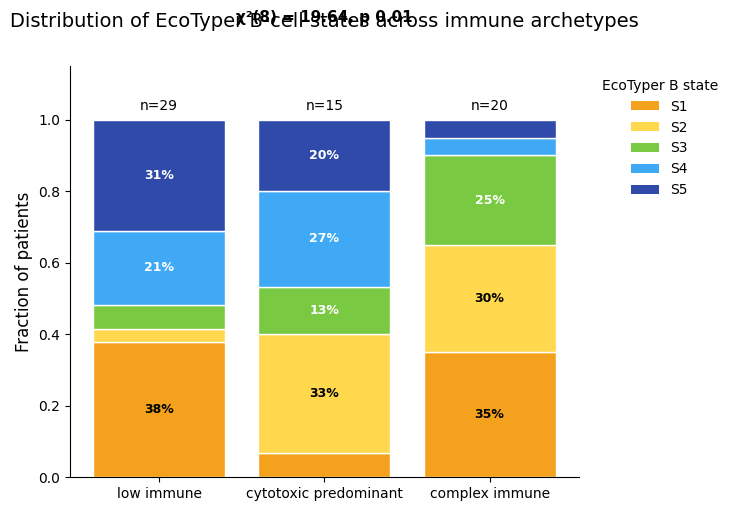

Saved: figures/fig3/fig3M_ecotyper_b_state_by_archetype.svg
Saved: figures/fig3/fig3M_ecotyper_b_state_by_archetype.png
Saved: figures/fig3/fig3M_ecotyper_b_state_by_archetype.pdf
Saved: figures/fig3/bcell_state_ecotyper/ecotyper_b_state_by_archetype_chisq_stats.csv


In [17]:
# ============================================================
# EcoTyper B-cell states by immune archetype
# Saves SVG + PNG
# Adds global chi-square test: archetype x B-cell state
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTDIR = Path(str(FIG_DIR) + "/bcell_state_ecotyper")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Figure aesthetics
# ------------------------------------------------------------

mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

state_order = ["S01", "S02", "S03", "S04", "S05"]

state_colors = {
    "S01": "#f4a21d",
    "S02": "#ffd84d",
    "S03": "#7ac943",
    "S04": "#3fa9f5",
    "S05": "#2f4aa8",
}

state_labels = {
    "S01": "S1",
    "S02": "S2",
    "S03": "S3",
    "S04": "S4",
    "S05": "S5",
}

archetype_order = [
    "low immune",
    "cytotoxic predominant",
    "complex immune",
]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def format_p(p):
    if pd.isna(p):
        return "NA"
    elif p < 1e-4:
        return "<0.0001"
    elif p < 1e-3:
        return "<0.001"
    elif p < 1e-2:
        return "<0.01"
    else:
        return f"{p:.2f}"

# ------------------------------------------------------------
# EcoTyper table
# ------------------------------------------------------------

bstate = pd.DataFrame(adata.uns["ecotyper_b_state"]).copy()
bstate.index = bstate.index.astype(str)
bstate.index.name = "patient_id"

bstate["Dominant_B_cell_state"] = (
    bstate["Dominant_B_cell_state"]
    .astype(str)
    .str.upper()
    .str.replace("S1", "S01", regex=False)
    .str.replace("S2", "S02", regex=False)
    .str.replace("S3", "S03", regex=False)
    .str.replace("S4", "S04", regex=False)
    .str.replace("S5", "S05", regex=False)
)

# ------------------------------------------------------------
# Archetypes
# ------------------------------------------------------------

case_class = pd.DataFrame(adata.uns["case_classifications"]).copy()

if "patient_id" in case_class.columns:
    case_class["patient_id"] = case_class["patient_id"].astype(str)
    case_class = case_class.set_index("patient_id")
else:
    case_class.index = case_class.index.astype(str)
    case_class.index.name = "patient_id"

archetype_col = "abundance_cluster_30_label"

if archetype_col not in case_class.columns:
    raise ValueError(
        f"{archetype_col} not found.\n"
        f"Available columns:\n{case_class.columns.tolist()}"
    )

# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------

plot_df = (
    bstate[["Dominant_B_cell_state"]]
    .join(case_class[[archetype_col]], how="inner")
    .dropna()
)

plot_df = plot_df[
    plot_df["Dominant_B_cell_state"].isin(state_order)
]

print(f"Patients included: {len(plot_df)}")

# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

count_tab = pd.crosstab(
    plot_df[archetype_col],
    plot_df["Dominant_B_cell_state"],
)

count_tab = count_tab.reindex(
    index=[x for x in archetype_order if x in count_tab.index],
    columns=state_order,
    fill_value=0,
)

prop_tab = (
    count_tab
    .div(count_tab.sum(axis=1), axis=0)
    .fillna(0)
)

display(count_tab)

log_saved(write_supplementary_table(count_tab.reset_index(names="archetype"), REPO_ROOT, "fig3M_ecotyper_counts"), REPO_ROOT)
log_saved(write_supplementary_table(prop_tab.reset_index(names="archetype"), REPO_ROOT, "fig3M_ecotyper_proportions"), REPO_ROOT)

# ------------------------------------------------------------
# Chi-square test: archetype x EcoTyper B-cell state
# ------------------------------------------------------------

chi2, p_val, dof, expected = chi2_contingency(count_tab)

expected_tab = pd.DataFrame(
    expected,
    index=count_tab.index,
    columns=count_tab.columns,
)

stats_df = pd.DataFrame([{
    "test": "Chi-square",
    "comparison": "immune archetype x EcoTyper B-cell state",
    "chi2": chi2,
    "dof": dof,
    "p": p_val,
    "p_label": format_p(p_val),
    "min_expected_count": expected_tab.min().min(),
}])

print("\n=== Global EcoTyper B-state association ===")
display(stats_df)

print("\n=== Expected counts ===")
display(expected_tab.round(2))

stats_df.to_csv(
    OUTDIR / "ecotyper_b_state_by_archetype_chisq_stats.csv",
    index=False,
)

expected_tab.to_csv(
    OUTDIR / "ecotyper_b_state_by_archetype_expected_counts.csv"
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.4, 5.2))

x = np.arange(len(prop_tab.index))
bottom = np.zeros(len(prop_tab))

for state in state_order:

    vals = prop_tab[state].values

    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=state_colors[state],
        edgecolor="white",
        linewidth=1,
    )

    for i, v in enumerate(vals):

        if v < 0.08:
            continue

        ax.text(
            i,
            bottom[i] + (v / 2),
            f"{v*100:.0f}%",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="black" if state in ["S01", "S02"] else "white",
        )

    bottom += vals

# ------------------------------------------------------------
# Sample size labels
# ------------------------------------------------------------

for i, arch in enumerate(prop_tab.index):

    n_patients = int(count_tab.loc[arch].sum())

    ax.text(
        i,
        1.02,
        f"n={n_patients}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# ------------------------------------------------------------
# Statistics label
# ------------------------------------------------------------

ax.text(
    0.5,
    1.10,
    f"χ²({int(dof)}) = {chi2:.2f}, p {format_p(p_val)}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(prop_tab.index)

ax.set_ylim(0, 1.15)

ax.set_ylabel(
    "Fraction of patients",
    fontsize=12,
)

ax.set_xlabel("")

ax.set_title(
    "Distribution of EcoTyper B-cell states across immune archetypes",
    fontsize=14,
    pad=28,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=state_colors[s],
        edgecolor="none",
        label=state_labels[s],
    )
    for s in state_order
]

ax.legend(
    handles=legend_handles,
    title="EcoTyper B state",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

svg_file = FIG_DIR / "fig3M_ecotyper_b_state_by_archetype.svg"
png_file = FIG_DIR / "fig3M_ecotyper_b_state_by_archetype.png"
pdf_file = FIG_DIR / "fig3M_ecotyper_b_state_by_archetype.pdf"

fig.savefig(svg_file, bbox_inches="tight")
fig.savefig(png_file, dpi=300, bbox_inches="tight")
fig.savefig(pdf_file, bbox_inches="tight")

plt.show()

log_saved(svg_file, REPO_ROOT)
log_saved(png_file, REPO_ROOT)
log_saved(pdf_file, REPO_ROOT)
log_saved(OUTDIR / 'ecotyper_b_state_by_archetype_chisq_stats.csv', REPO_ROOT)


## Fig 3O — GSEA dotplot (archetype, patient-level)

Primary panel: **MSigDB Hallmark** gene sets (patient-level one-vs-rest ranking). Paper outputs are written to `figures/fig3/fig3O_gsea_archetypes_hallmark.{svg,png}`; enrichment tables stay under `figures/fig3/gsea_abundance_cluster_30_patientlevel/`.


Expression patients: 67
Metadata patients: 64
Overlap patients: 64

Final X shape: (64, 797)
Class counts:
cluster_name
low immune               29
cytotoxic predominant    15
complex immune           20
Name: count, dtype: int64

RUNNING GSEA

=== low immune ===
n pos=29, n rest=35
n genes ranked: 797
score range: -5.894 to 4.288


Top pathways:


,Term,NES,fdr
0,E2F Targets,3.218444,1.619162e-11
1,Myc Targets V1,3.087776,3.903528e-09
4,Epithelial Mesenchymal Transition,-2.026470,5.560025e-06
3,G2-M Checkpoint,2.536761,1.066651e-05
2,Myc Targets V2,2.554773,1.442831e-05
5,Inflammatory Response,-1.845094,2.800981e-04
6,KRAS Signaling Up,-1.839065,1.054797e-03
11,TNF-alpha Signaling via NF-kB,-1.738911,1.054797e-03
9,Interferon Gamma Response,-1.755104,1.090913e-03
7,Complement,-1.812346,1.558484e-03



=== cytotoxic predominant ===
n pos=15, n rest=49
n genes ranked: 797
score range: -4.036 to 7.371
Top pathways:


,Term,NES,fdr
0,Interferon Gamma Response,2.247404,7.439610e-07
1,Interferon Alpha Response,1.996987,8.676202e-04
3,Epithelial Mesenchymal Transition,-1.863687,9.063274e-04
2,IL-6/JAK/STAT3 Signaling,1.907690,1.817705e-03
4,Complement,1.851339,3.367994e-03
5,Inflammatory Response,1.799604,4.034529e-03
6,KRAS Signaling Up,1.780594,4.034529e-03
8,Allograft Rejection,1.648714,4.406310e-03
7,IL-2/STAT5 Signaling,1.691109,1.058726e-02
9,UV Response Dn,-1.636121,2.477595e-02


...

Top pathways:


,Term,NES,fdr
0,Myc Targets V1,-3.167093,6.344418e-10
1,E2F Targets,-2.918899,6.811217e-08
3,Epithelial Mesenchymal Transition,2.374944,7.065247e-08
2,Myc Targets V2,-2.465441,6.648440e-05
4,G2-M Checkpoint,-2.306612,3.798394e-04
5,Oxidative Phosphorylation,-2.106724,2.318554e-03
6,Coagulation,1.847279,5.978142e-03
7,UV Response Dn,1.830522,9.699862e-03
8,Myogenesis,1.784020,1.610320e-02
10,p53 Pathway,-1.564353,3.390112e-02


Saved: data/supplementary/fig3/fig3O_gsea_long.csv

gsea_long shape: (111, 10)
Saved: data/supplementary/fig3/fig3O_gsea_NES.csv
Saved: data/supplementary/fig3/fig3O_gsea_FDR.csv


Saved SVG → figures/fig3/fig3O_gsea_archetypes_hallmark.svg
Saved PNG → figures/fig3/fig3O_gsea_archetypes_hallmark.png


/var/folders/k_/ffwscldj7gx7ch29c5ffhr4c0000gn/T/ipykernel_42803/2906932042.py:354: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  nes_sel.stack(dropna=False)
/var/folders/k_/ffwscldj7gx7ch29c5ffhr4c0000gn/T/ipykernel_42803/2906932042.py:358: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  fdr_sel.stack(dropna=False).rename("fdr"),


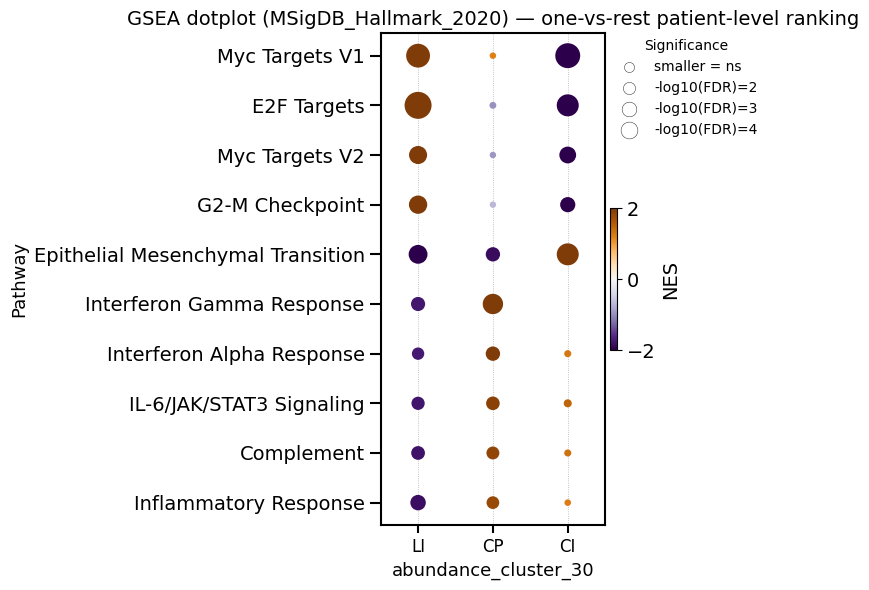


Saved outputs to:
figures/fig3/gsea_abundance_cluster_30_patientlevel


In [18]:
# ============================================================
# GSEA DOTPLOT — patient-level one-vs-rest ranking
# Aesthetics matched to previous GSEA dotplot cell
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind
import gseapy as gp

# =========================
# SETTINGS
# =========================
GENESETS = "MSigDB_Hallmark_2020"
# Classic gene-set permutation floors nominal p at ~1/nperm and prints 0 for
# stronger hits. fgsea multilevel resolves p << 1/nperm without huge nperm cost.
PERMUTATIONS = 1000
GSEA_METHOD = "multilevel"
MIN_SIZE = 8
MAX_SIZE = 300
SEED = 42

FDR_TH = 0.25
TOP_M = 10
DIFF_METRIC = "range"

SIZE_CAP = 14.0
SIZE_SCALE = 35.0
CMAP = "PuOr_r"

SAVE_SVG = True
SAVE_PNG = True
FIG_NAME = "fig3O_gsea_archetypes_hallmark"

# Analysis tables stay in a descriptive subfolder; paper panel goes to FIG_DIR root.
GSEA_OUTDIR = Path(FIG_DIR) / "gsea_abundance_cluster_30_patientlevel"
GSEA_OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["svg.fonttype"] = "none"

# =========================
# INPUTS
# =========================
cluster_name_map = {
    1: "low immune",
    2: "cytotoxic predominant",
    3: "complex immune",
}

cluster_order_raw = [1, 2, 3]
cluster_order = [cluster_name_map[k] for k in cluster_order_raw]
col_labels = ["LI", "CP", "CI"]

expr = adata.uns["gene_expression"].copy()        # genes x patients
meta = adata.uns["case_classifications"].copy()

if "patient_id" not in meta.columns:
    meta["patient_id"] = meta.index.astype(str)

expr.index = expr.index.astype(str).str.strip()
expr.columns = expr.columns.astype(str).str.strip()
meta["patient_id"] = meta["patient_id"].astype(str).str.strip()

meta = meta.drop_duplicates("patient_id").set_index("patient_id")

common = expr.columns.intersection(meta.index)

print("Expression patients:", expr.shape[1])
print("Metadata patients:", meta.shape[0])
print("Overlap patients:", len(common))

expr = expr.loc[:, common].copy()
meta = meta.loc[common].copy()

def map_cluster(x):
    if pd.isna(x):
        return np.nan
    try:
        return cluster_name_map.get(int(float(x)), str(x))
    except Exception:
        return str(x)

meta["cluster_name"] = meta["abundance_cluster_30"].map(map_cluster)

keep = meta["cluster_name"].isin(cluster_order)
expr = expr.loc[:, keep].copy()
meta = meta.loc[keep].copy()

X = expr.T.copy()  # patients x genes
y = meta["cluster_name"].copy()

# drop all-NA / zero variance genes
X = X.loc[:, X.notna().any(axis=0)]
gene_var = X.var(axis=0, ddof=1)
X = X.loc[:, gene_var.fillna(0) > 0].copy()

# impute remaining missing by gene median
X = X.apply(lambda s: s.fillna(s.median()), axis=0)

print("\nFinal X shape:", X.shape)
print("Class counts:")
print(y.value_counts().reindex(cluster_order))

# =========================
# HELPERS
# =========================
def _standardize_gseapy_res(res2d):
    res = res2d.copy()

    if res.empty:
        return pd.DataFrame(columns=["Term", "NES", "fdr"])

    if "Term" not in res.columns:
        res = res.reset_index().rename(columns={"index": "Term"})

    if "FDR q-val" in res.columns:
        res = res.rename(columns={"FDR q-val": "fdr"})

    if "NOM p-val" in res.columns:
        res = res.rename(columns={"NOM p-val": "pval"})

    if "Lead genes" in res.columns:
        res = res.rename(columns={"Lead genes": "Lead_genes"})

    if "fdr" not in res.columns:
        res["fdr"] = np.nan

    keep_cols = [
        c for c in [
            "Term", "NES", "ES", "pval", "fdr",
            "Lead_genes", "Tag %", "Gene %"
        ]
        if c in res.columns
    ]

    res = res[keep_cols].copy()

    for c in ["NES", "ES", "pval", "fdr"]:
        if c in res.columns:
            res[c] = pd.to_numeric(res[c], errors="coerce")

    return res


def _safe_neglog10_fdr(fdr, cap=SIZE_CAP):
    f = np.asarray(fdr, dtype=float)
    f = np.clip(f, 1e-300, 1.0)
    val = -np.log10(f)
    return np.clip(val, 0, cap)


def _make_rank_vector_one_vs_rest(X, y, positive_class, min_group_n=2):
    mask_pos = (y == positive_class).values
    mask_neg = ~mask_pos

    n_pos = int(mask_pos.sum())
    n_neg = int(mask_neg.sum())

    if n_pos < min_group_n or n_neg < min_group_n:
        raise ValueError(
            f"{positive_class}: too few samples for one-vs-rest "
            f"({n_pos} vs {n_neg})"
        )

    A = X.iloc[mask_pos, :]
    B = X.iloc[mask_neg, :]

    mean_A = A.mean(axis=0)
    mean_B = B.mean(axis=0)
    diff = mean_A - mean_B

    t_stat, pval = ttest_ind(
        A.values,
        B.values,
        axis=0,
        equal_var=False,
        nan_policy="omit",
    )

    res = pd.DataFrame({
        "gene": X.columns.astype(str),
        "stat": t_stat,
        "diff": diff.values,
        "pval": pval,
    })

    res = res.replace([np.inf, -np.inf], np.nan)
    res = res.dropna(subset=["gene", "stat"])

    # collapse duplicate gene names if needed
    res = (
        res
        .groupby("gene", as_index=False)
        .agg(
            stat=("stat", "mean"),
            diff=("diff", "mean"),
            pval=("pval", "mean"),
        )
    )

    # tiny diff tie-breaker
    res["rank_score"] = res["stat"] + 1e-9 * res["diff"]

    # tiny random jitter to reduce exact GSEA ties
    rng = np.random.default_rng(SEED)
    res["rank_score"] = res["rank_score"] + rng.normal(0, 1e-10, size=len(res))

    res = res.sort_values("rank_score", ascending=False).reset_index(drop=True)

    return res


# =========================
# 1) Run per-class GSEA
# =========================
all_rows = []
rank_tables = {}

print("\n=========================")
print("RUNNING GSEA")
print("=========================")

for cls in cluster_order:
    print(f"\n=== {cls} ===")

    rank_df = _make_rank_vector_one_vs_rest(X, y, cls)
    rank_tables[cls] = rank_df

    rnk = rank_df.set_index("gene")["rank_score"].sort_values(ascending=False)

    safe_cls = cls.replace(" ", "_").replace("/", "_")

    rank_df.to_csv(
        GSEA_OUTDIR / f"rank_table_one_vs_rest_{safe_cls}.csv",
        index=False,
    )

    rnk.to_csv(
        GSEA_OUTDIR / f"prerank_one_vs_rest_{safe_cls}.rnk",
        sep="\t",
        header=False,
    )

    print(f"n pos={int((y == cls).sum())}, n rest={int((y != cls).sum())}")
    print(f"n genes ranked: {len(rnk)}")
    print(f"score range: {rnk.min():.4g} to {rnk.max():.4g}")

    g = gp.prerank(
        rnk=rnk,
        gene_sets=GENESETS,
        permutation_num=PERMUTATIONS,
        min_size=MIN_SIZE,
        max_size=MAX_SIZE,
        outdir=None,
        seed=SEED,
        verbose=False,
        method=GSEA_METHOD,
    )

    res_std = _standardize_gseapy_res(g.res2d)

    if res_std.empty:
        print(f"No enriched pathways returned for {cls}")
        continue

    res_std["cluster_name"] = cls
    res_std["cluster_short"] = {
        "low immune": "LI",
        "cytotoxic predominant": "CP",
        "complex immune": "CI",
    }.get(cls, cls)

    res_std.to_csv(
        GSEA_OUTDIR / f"gsea_one_vs_rest_{safe_cls}.csv",
        index=False,
    )

    all_rows.append(res_std)

    print("Top pathways:")
    display(res_std.sort_values("fdr").head(10)[["Term", "NES", "fdr"]])

if len(all_rows) == 0:
    raise ValueError("No GSEA result tables were generated.")

gsea_long = pd.concat(all_rows, ignore_index=True)
gsea_long.to_csv(GSEA_OUTDIR / "gsea_one_vs_rest_long.csv", index=False)
log_saved(write_supplementary_table(gsea_long, REPO_ROOT, "fig3O_gsea_long"), REPO_ROOT)

print("\ngsea_long shape:", gsea_long.shape)

# =========================
# 2) Build pathway x class matrices
# =========================
nes_mat = gsea_long.pivot_table(
    index="Term",
    columns="cluster_name",
    values="NES",
    aggfunc="first",
)

fdr_mat = gsea_long.pivot_table(
    index="Term",
    columns="cluster_name",
    values="fdr",
    aggfunc="first",
)

nes_mat = nes_mat.reindex(columns=cluster_order)
fdr_mat = fdr_mat.reindex(columns=cluster_order)

# =========================
# 3) Select pathways
# =========================
if DIFF_METRIC == "range":
    diff_metric = nes_mat.max(axis=1) - nes_mat.min(axis=1)
elif DIFF_METRIC == "std":
    diff_metric = nes_mat.std(axis=1)
else:
    raise ValueError("DIFF_METRIC must be 'range' or 'std'")

valid = nes_mat.notna().sum(axis=1) >= 2
min_fdr = fdr_mat.min(axis=1)
max_abs_nes = nes_mat.abs().max(axis=1)

FDR_TH_LOOSE = 0.25
NES_MIN = 1.5

keep_terms = valid & ((min_fdr <= FDR_TH_LOOSE) | (max_abs_nes >= NES_MIN))

sel = diff_metric.loc[keep_terms].sort_values(ascending=False)

if sel.empty:
    raise ValueError(
        "No pathways pass selection; try FDR_TH_LOOSE=0.5 or NES_MIN=1.25"
    )

terms_keep = sel.head(TOP_M).index.tolist()

nes_sel = nes_mat.loc[terms_keep].copy()
fdr_sel = fdr_mat.loc[terms_keep].copy()

nes_sel.to_csv(GSEA_OUTDIR / "selected_pathway_NES_matrix.csv")
fdr_sel.to_csv(GSEA_OUTDIR / "selected_pathway_FDR_matrix.csv")
log_saved(write_supplementary_table(nes_sel, REPO_ROOT, "fig3O_gsea_NES", index=True), REPO_ROOT)
log_saved(write_supplementary_table(fdr_sel, REPO_ROOT, "fig3O_gsea_FDR", index=True), REPO_ROOT)

# =========================
# 4) Dotplot
# =========================
plot_df = (
    nes_sel.stack(dropna=False)
    .rename("NES")
    .to_frame()
    .join(
        fdr_sel.stack(dropna=False).rename("fdr"),
        how="left",
    )
    .reset_index()
    .rename(columns={"level_0": "Term", "level_1": "cluster_name"})
)

plot_df["neglog10_fdr"] = _safe_neglog10_fdr(
    plot_df["fdr"].values,
    cap=SIZE_CAP,
)

sig_mask = plot_df["fdr"] <= FDR_TH

plot_df["size"] = 0.0
plot_df.loc[sig_mask, "size"] = (
    plot_df.loc[sig_mask, "neglog10_fdr"] * SIZE_SCALE
)

x_map = {cls: i for i, cls in enumerate(cluster_order)}
y_terms = list(nes_sel.index)
y_map = {t: i for i, t in enumerate(y_terms)}

plot_df["x"] = plot_df["cluster_name"].map(x_map)
plot_df["y"] = plot_df["Term"].map(y_map)

v = np.nanmax(np.abs(plot_df["NES"].values))
v = float(v) if np.isfinite(v) and v > 0 else 1.0
v = max(v, 2.0)

fig_w = max(7, 1.25 * len(cluster_order))
fig_h = max(6, 0.40 * len(y_terms) + 2)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sc = ax.scatter(
    plot_df["x"],
    plot_df["y"],
    c=plot_df["NES"],
    s=plot_df["size"],
    cmap=CMAP,
    vmin=-2,
    vmax=2,
    edgecolors="none",
)

ax.set_xlim(-0.5, len(cluster_order) - 0.5)
ax.set_xticks(range(len(cluster_order)))
ax.set_xticklabels(col_labels, rotation=0, fontsize=12)

ax.set_yticks(range(len(y_terms)))
ax.set_yticklabels(y_terms, fontsize=14)

ax.invert_yaxis()

ax.set_xlabel("abundance_cluster_30", fontsize=13)
ax.set_ylabel("Pathway", fontsize=13)
ax.set_title(
    f"GSEA dotplot ({GENESETS}) — one-vs-rest patient-level ranking",
    fontsize=14,
)

ax.set_facecolor("white")
ax.set_axisbelow(True)

ax.grid(
    True,
    which="major",
    axis="x",
    linestyle=":",
    linewidth=0.6,
    color="0.7",
)
ax.grid(False, axis="y")

for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1.5)

ax.tick_params(
    axis="y",
    which="major",
    left=True,
    right=False,
    length=8,
    width=1.5,
    colors="black",
    direction="out",
)

ax.tick_params(
    axis="x",
    which="major",
    bottom=True,
    top=False,
    length=6,
    width=1.5,
    colors="black",
    direction="out",
)

cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_ticks([-2, 0, 2])
cbar.set_label("NES", fontsize=14)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()

legend_vals = [1.3, 2, 3, 4]
legend_vals = [vv for vv in legend_vals if vv <= SIZE_CAP]

handles = []
labels = []

for nv in legend_vals:
    s = (nv + 0.2) * SIZE_SCALE
    handles.append(
        ax.scatter(
            [],
            [],
            s=s,
            c="white",
            edgecolors="black",
            linewidths=0.3,
        )
    )
    labels.append("smaller = ns" if nv == 1.3 else f"-log10(FDR)={nv:g}")

ax.legend(
    handles,
    labels,
    title="Significance",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
)

if SAVE_SVG:
    outpath = FIG_DIR / f"{FIG_NAME}.svg"
    fig.savefig(outpath, format="svg", bbox_inches="tight")
    print(f"Saved SVG → {rel_path(outpath, REPO_ROOT)}")

if SAVE_PNG:
    outpath = FIG_DIR / f"{FIG_NAME}.png"
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    print(f"Saved PNG → {rel_path(outpath, REPO_ROOT)}")

plt.show()

print("\nSaved outputs to:")
print(rel_path(GSEA_OUTDIR, REPO_ROOT))


### Fig 3O (alternative) — GSEA ImmuneSigDB (removed)

The ImmuneSigDB / MSigDB C7 alternative GSEA panel was dropped from the public
reproduction notebooks to keep runtime modest and avoid a second large
permutation/enrichment pass. Hallmark GSEA above is the manuscript panel (Fig 3O).


In [19]:
# C7 / ImmuneSigDB GSEA intentionally omitted (see markdown cell above).
print("Skipping ImmuneSigDB (C7) GSEA — Hallmark panel is Fig 3O.")


Skipping ImmuneSigDB (C7) GSEA — Hallmark panel is Fig 3O.


## Fig S3E — HLA class I/II status × immune archetype


=== HLAABC counts ===


/var/folders/k_/ffwscldj7gx7ch29c5ffhr4c0000gn/T/ipykernel_42803/1895755402.py:60: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[col] = out[col].replace({


HLAABC,loss,retained,missing
abundance_cluster,,,
low immune,19,9,1
cytotoxic predominant,10,5,0
complex immune,10,10,0



=== HLAABC percentages ===


HLAABC,loss,retained,missing
abundance_cluster,,,
low immune,65.5,31.0,3.4
cytotoxic predominant,66.7,33.3,0.0
complex immune,50.0,50.0,0.0


...


=== HLADR percentages ===


HLADR,loss,retained,missing
abundance_cluster,,,
low immune,37.9,62.1,0.0
cytotoxic predominant,46.7,53.3,0.0
complex immune,10.0,90.0,0.0



=== HLA global stats ===


,marker,test,chi2,dof,p,p_label
0,HLAABC,"Chi-square, archetype x loss/retained",1.766827,2,0.413369,0.41
1,HLADR,"Chi-square, archetype x loss/retained",6.465538,2,0.039448,0.04


Saved: data/supplementary/fig3/fig3N_HLA_global_stats.csv
Saved: data/supplementary/fig3/fig3N_HLA_counts.csv
Saved: data/supplementary/fig3/fig3N_HLA_percentages.csv


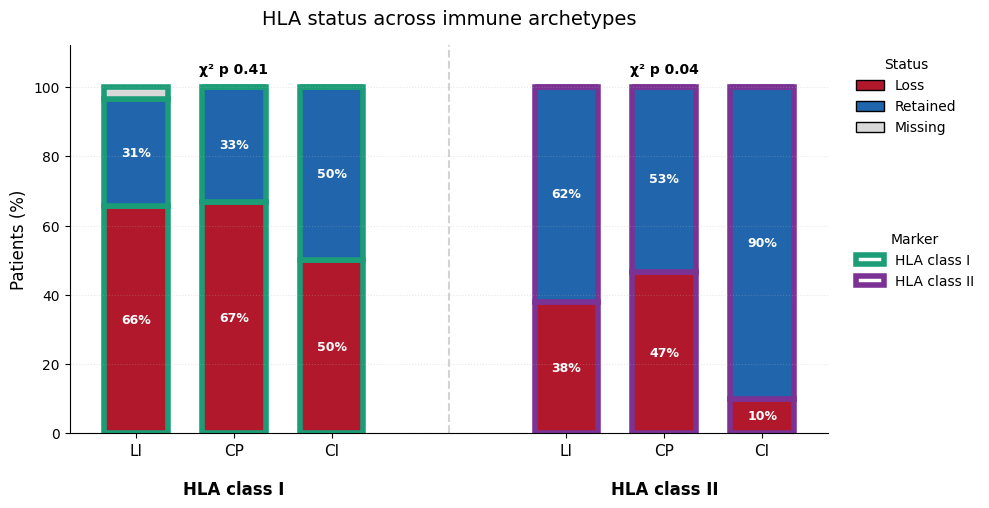


Saved:
figures/fig3/figS3E_HLA_archetype_stacked.png
figures/fig3/figS3E_HLA_archetype_stacked.svg
figures/fig3/figS3E_HLA_archetype_stacked.pdf
figures/fig3/classifier_associations/HLAABC_HLADR_global_stats.csv


In [20]:
# ============================================================
# COMBINED HLAABC + HLADR STACKED BARPLOT BY IMMUNE ARCHETYPE
# WITH GLOBAL STATS PER HLA CLASS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# Build association_df (HLA + archetype labels)
# ------------------------------------------------------------
OUTDIR = FIG_DIR / "classifier_associations"
OUTDIR.mkdir(parents=True, exist_ok=True)
PAPER_STEM = FIG_DIR / "figS3E_HLA_archetype_stacked"

ABUNDANCE_SOURCE_COL = "abundance_cluster_30_label"
ABUNDANCE_OUTPUT_COL = "abundance_cluster"
HLA_COLS = ["HLAABC", "HLADR"]


def as_patient_index(df):
    df = pd.DataFrame(df).copy()
    if "patient_id" in df.columns:
        df["patient_id"] = df["patient_id"].astype(str)
        df = df.set_index("patient_id")
    df.index = df.index.astype(str)
    df.index.name = "patient_id"
    return df


def clean_hla_call(s):
    return (
        s.astype("object")
         .replace({
             0: "loss",
             1: "retained",
             0.0: "loss",
             1.0: "retained",
             "0": "loss",
             "1": "retained",
             "0.0": "loss",
             "1.0": "retained",
             "UNK": pd.NA,
             "unknown": pd.NA,
             "Unknown": pd.NA,
             "nan": pd.NA,
             "": pd.NA,
         })
    )


def clean_categorical_df(df):
    out = df.copy()
    for col in out.columns:
        out[col] = out[col].astype("object")
        out[col] = out[col].replace({
            "nan": pd.NA,
            "NaN": pd.NA,
            "None": pd.NA,
            "NA": pd.NA,
            "N/A": pd.NA,
            "UNK": pd.NA,
            "unknown": pd.NA,
            "Unknown": pd.NA,
            "": pd.NA,
        })
    for col in HLA_COLS:
        if col in out.columns:
            out[col] = clean_hla_call(out[col])
    return out


case_classifications = as_patient_index(adata.uns["case_classifications"])
case_path = as_patient_index(adata.uns["case_path"])

base_cols = [c for c in [ABUNDANCE_SOURCE_COL, *HLA_COLS] if c in case_classifications.columns]
association_df = case_classifications[base_cols].copy()
missing_hla = [
    c for c in HLA_COLS
    if c not in association_df.columns and c in case_path.columns
]
if missing_hla:
    association_df = association_df.join(case_path[missing_hla], how="outer")

if ABUNDANCE_SOURCE_COL in association_df.columns:
    association_df = association_df.rename(columns={ABUNDANCE_SOURCE_COL: ABUNDANCE_OUTPUT_COL})
association_df = clean_categorical_df(association_df)

os.makedirs(OUTDIR, exist_ok=True)

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["svg.fonttype"] = "none"

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

archetype_col = "abundance_cluster"

archetype_order = [
    "low immune",
    "cytotoxic predominant",
    "complex immune",
]

short_labels = {
    "low immune": "LI",
    "cytotoxic predominant": "CP",
    "complex immune": "CI",
}

hla_cols = ["HLAABC", "HLADR"]

hla_group_labels = {
    "HLAABC": "HLA class I",
    "HLADR": "HLA class II",
}

hla_edge_colors = {
    "HLAABC": "#1b9e77",
    "HLADR": "#7b3294",
}

status_order = ["loss", "retained", "missing"]

status_colors = {
    "loss": "#b2182b",
    "retained": "#2166ac",
    "missing": "#d9d9d9",
}

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def format_p(p):
    if pd.isna(p):
        return "NA"
    elif p < 1e-4:
        return "<0.0001"
    elif p < 1e-3:
        return "<0.001"
    elif p < 1e-2:
        return "<0.01"
    else:
        return f"{p:.2f}"


def make_hla_pct_table(association_df, hla_col, archetype_col):
    tmp = association_df[[hla_col, archetype_col]].copy()

    tmp[hla_col] = tmp[hla_col].fillna("missing")
    tmp[archetype_col] = tmp[archetype_col].fillna("missing")

    table = pd.crosstab(
        tmp[archetype_col],
        tmp[hla_col],
    ).reindex(
        index=archetype_order,
        columns=status_order,
        fill_value=0,
    )

    pct = table.div(table.sum(axis=1), axis=0) * 100

    return table, pct


def hla_global_chisq(table):
    # Global 3 x 2 test: archetype vs loss/retained
    # Missing excluded from inferential test.
    test_table = table[["loss", "retained"]].copy()

    if test_table.values.sum() == 0:
        return np.nan, np.nan, np.nan

    chi2, p, dof, expected = chi2_contingency(test_table)

    return chi2, p, dof


# ------------------------------------------------------------
# BUILD TABLES + STATS
# ------------------------------------------------------------

tables = {}
pcts = {}
stats_rows = []

for hla_col in hla_cols:

    table, pct = make_hla_pct_table(
        association_df=association_df,
        hla_col=hla_col,
        archetype_col=archetype_col,
    )

    tables[hla_col] = table
    pcts[hla_col] = pct

    chi2, p, dof = hla_global_chisq(table)

    stats_rows.append({
        "marker": hla_col,
        "test": "Chi-square, archetype x loss/retained",
        "chi2": chi2,
        "dof": dof,
        "p": p,
        "p_label": format_p(p),
    })

    print(f"\n=== {hla_col} counts ===")
    display(table)

    print(f"\n=== {hla_col} percentages ===")
    display(pct.round(1))

hla_stats_df = pd.DataFrame(stats_rows)

print("\n=== HLA global stats ===")
display(hla_stats_df)

hla_stats_df.to_csv(
    OUTDIR / "HLAABC_HLADR_global_stats.csv",
    index=False,
)
log_saved(write_supplementary_table(hla_stats_df, REPO_ROOT, "fig3N_HLA_global_stats"), REPO_ROOT)
hla_counts = pd.concat(tables, names=["marker"]).reset_index(level=0).reset_index()
hla_percentages = pd.concat(pcts, names=["marker"]).reset_index(level=0).reset_index()
log_saved(write_supplementary_table(hla_counts, REPO_ROOT, "fig3N_HLA_counts"), REPO_ROOT)
log_saved(write_supplementary_table(hla_percentages, REPO_ROOT, "fig3N_HLA_percentages"), REPO_ROOT)

# ------------------------------------------------------------
# COMBINED STACKED BARPLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.2))

bar_width = 0.65
block_gap = 1.4

n_arch = len(archetype_order)

x_class1 = np.arange(n_arch)
x_class2 = np.arange(n_arch) + n_arch + block_gap

xpos_map = {
    "HLAABC": x_class1,
    "HLADR": x_class2,
}

for hla_col in hla_cols:

    pct = pcts[hla_col]
    xpos = xpos_map[hla_col]

    bottom = np.zeros(len(pct))

    for status in status_order:

        vals = pct[status].values.astype(float)

        ax.bar(
            xpos,
            vals,
            width=bar_width,
            bottom=bottom,
            color=status_colors[status],
            edgecolor=hla_edge_colors[hla_col],
            linewidth=4.0,
        )

        for i, v in enumerate(vals):
            if v >= 7:
                ax.text(
                    xpos[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color="white" if status != "missing" else "black",
                )

        bottom += vals

# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

all_x = np.concatenate([x_class1, x_class2])

ax.set_xticks(all_x)
ax.set_xticklabels(
    [short_labels[a] for a in archetype_order] * 2,
    fontsize=11,
)

ax.set_ylim(0, 112)
ax.set_ylabel("Patients (%)", fontsize=12)

ax.set_title(
    "HLA status across immune archetypes",
    fontsize=14,
    pad=15,
)

# ------------------------------------------------------------
# GROUP LABELS
# ------------------------------------------------------------

ax.text(
    x_class1.mean(),
    -0.12,
    "HLA class I",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)

ax.text(
    x_class2.mean(),
    -0.12,
    "HLA class II",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)

sep_x = (x_class1[-1] + x_class2[0]) / 2

ax.axvline(
    sep_x,
    color="lightgray",
    linestyle="--",
    linewidth=1.5,
    zorder=0,
)

# ------------------------------------------------------------
# STATS ANNOTATIONS
# ------------------------------------------------------------

for hla_col, xpos in xpos_map.items():

    p_label = hla_stats_df.loc[
        hla_stats_df["marker"] == hla_col,
        "p_label",
    ].iloc[0]

    ax.text(
        xpos.mean(),
        103,
        f"χ² p {p_label}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        clip_on=False,
    )

# ------------------------------------------------------------
# STYLE
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.3,
)

# ------------------------------------------------------------
# LEGENDS
# ------------------------------------------------------------

status_handles = [
    Patch(
        facecolor=status_colors[s],
        edgecolor="black",
        label=s.capitalize(),
    )
    for s in status_order
]

hla_handles = [
    Patch(
        facecolor="white",
        edgecolor=hla_edge_colors[h],
        linewidth=4,
        label=hla_group_labels[h],
    )
    for h in hla_cols
]

leg1 = ax.legend(
    handles=status_handles,
    title="Status",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
)

ax.add_artist(leg1)

ax.legend(
    handles=hla_handles,
    title="Marker",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.55),
    frameon=False,
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

plt.tight_layout()

png_file = str(PAPER_STEM.with_suffix(".png"))
svg_file = str(PAPER_STEM.with_suffix(".svg"))
pdf_file = str(PAPER_STEM.with_suffix(".pdf"))

plt.savefig(png_file, dpi=300, bbox_inches="tight")
plt.savefig(svg_file, bbox_inches="tight")
plt.savefig(pdf_file, bbox_inches="tight")

plt.show()

print("\nSaved:")
print(rel_path(png_file, REPO_ROOT))
print(rel_path(svg_file, REPO_ROOT))
print(rel_path(pdf_file, REPO_ROOT))
print(rel_path(OUTDIR / "HLAABC_HLADR_global_stats.csv", REPO_ROOT))
